# Superstitious Behavior in RL Agents — Extended Study

This notebook extends the pilot case study into a more rigorous, multi-condition
experiment, built to address the gaps a journal reviewer would flag:

1. **Multi-seed statistics** — every condition is run across multiple random seeds
   and reported as mean +/- std, with formal significance tests (Mann-Whitney U /
   Kruskal-Wallis) and effect sizes (Cohen's d), instead of single anecdotal runs.
2. **All three reward schedules** from the operant-conditioning literature: fixed
   interval, variable interval, and random (probabilistic) — not just fixed interval.
3. **A ritual-length / ritual-strength metric**, in addition to action entropy —
   this measures whether a *specific* action reliably precedes reward, which is
   closer to what Skinner's pigeons actually did than overall entropy alone.
4. **Four algorithms**: Q-learning, DQN, PPO, A2C — spanning bootstrapped
   (Q-learning, DQN), Monte-Carlo/GAE-based (PPO), and synchronous
   actor-critic (A2C) credit assignment.
5. **A curiosity-driven exploration bonus**, tested on/off.

In [ ]:
!pip install stable-baselines3 gymnasium scipy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, Counter

import gymnasium as gym
from gymnasium import spaces

from scipy.stats import mannwhitneyu, kruskal

# ---- Global configuration ----
N_SEEDS = 8            # seeds per condition. Reduce to 2-3 for a fast smoke test.
TOTAL_STEPS = 15000     # training steps per run
N_ACTIONS = 4
INTERVAL = 10           # mean steps between noncontingent rewards
WINDOW = 200            # trailing window size for entropy
LOG_EVERY = 300         # how often (in steps) to log entropy
RITUAL_TAIL = 30        # number of most-recent reward events used for ritual_strength

np.random.seed(0)


ALPHA = 0.05
N_BOOT = 10000           # bootstrap resamples used for 95% CIs on group differences
CI_LEVEL = 0.95
BOOT_SEED = 12345        # fixed seed for the bootstrap RNG, so CIs are reproducible run-to-run


import stable_baselines3 as _sb3
SB3_VERSION = _sb3.__version__
print("stable-baselines3 version:", SB3_VERSION)
N_SEEDS_PPO_EXT = 24     # seeds per PPO condition in Tiers B and C (seeds 0-7 identical to v2; 8-23 are new). Fixed in advance -- no optional stopping.
EQUIV_MARGIN = 0.5       # bits; equivalence margin used for the "no detectable effect" claims on PPO
RUN_TIER_D_SCHEDULES = True   # Q-learning variable/random at I=5,20 (cheap; tabular). Set False to skip.
N_NULL_SIMS = 2000       # simulations for the uniform-random-policy null baselines

stable-baselines3 version: 2.9.0


## 1. The Environment

Same core idea as the pilot: a single-state "Skinner box" with `N_ACTIONS` possible
actions. Extended to support:
- `schedule_type`: `"fixed"` (reward every `interval` steps), `"variable"` (reward
  after a randomly varying interval around the mean), `"random"` (reward each step
  with probability `1/interval`, i.e. no fixed clock at all — a memoryless schedule).
- `reward_mode`: `"noncontingent"` (the schedules above, reward is action-independent)
  or `"contingent"` (reward only for a specific `target_action` — the control).
- `curiosity_bonus`: optional count-based exploration bonus added on top of
  whatever extrinsic reward the schedule produces.

The `info` dict returned by `step()` always reports the **raw extrinsic reward**
separately from any curiosity bonus, so our behavioral metrics can track genuine
reward-timing events even when curiosity shaping is active.

In [ ]:
class SkinnerBoxEnv(gym.Env):
    """
    Minimal Skinner-box RL environment with configurable reward schedule,
    reward contingency, and an optional count-based curiosity bonus.
    """
    metadata = {"render_modes": []}

    def __init__(self, n_actions=4, interval=10, episode_len=500,
                 reward_mode="noncontingent", schedule_type="fixed",
                 target_action=0, curiosity_bonus=False, curiosity_coef=0.5,
                 seed=None):
        super().__init__()
        self.n_actions = n_actions
        self.interval = interval
        self.episode_len = episode_len
        self.reward_mode = reward_mode
        self.schedule_type = schedule_type
        self.target_action = target_action
        self.curiosity_bonus = curiosity_bonus
        self.curiosity_coef = curiosity_coef

        self.action_space = spaces.Discrete(n_actions)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)

        # Separate RNG that drives the reward schedule (kept apart from any
        # exploration RNG the agent itself uses).
        self._schedule_rng = np.random.default_rng(seed)
        self._step_count = 0
        self._global_step = 0
        self._action_counts = np.zeros(n_actions)
        self._next_reward_step = self._draw_next_reward_step()

    def _draw_next_reward_step(self):
        if self.schedule_type == "fixed":
            return self._global_step + self.interval
        elif self.schedule_type == "variable":
            # Variable interval: next reward drawn uniformly around the mean interval.
            low = max(1, int(self.interval * 0.5))
            high = int(self.interval * 1.5) + 1
            return self._global_step + int(self._schedule_rng.integers(low, high))
        elif self.schedule_type == "random":
            return None  # handled per-step probabilistically instead
        else:
            raise ValueError(f"Unknown schedule_type: {self.schedule_type}")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._step_count = 0
        obs = np.array([0.0], dtype=np.float32)
        return obs, {}

    def step(self, action):
        self._step_count += 1
        self._global_step += 1
        self._action_counts[action] += 1

        if self.reward_mode == "noncontingent":
            if self.schedule_type in ("fixed", "variable"):
                extrinsic = 1.0 if self._global_step >= self._next_reward_step else 0.0
                if extrinsic > 0:
                    self._next_reward_step = self._draw_next_reward_step()
            elif self.schedule_type == "random":
                extrinsic = 1.0 if self._schedule_rng.random() < (1.0 / self.interval) else 0.0
            else:
                raise ValueError(f"Unknown schedule_type: {self.schedule_type}")
        elif self.reward_mode == "contingent":
            extrinsic = 1.0 if action == self.target_action else 0.0
        else:
            raise ValueError(f"Unknown reward_mode: {self.reward_mode}")

        reward = extrinsic
        if self.curiosity_bonus:
            reward += self.curiosity_coef / np.sqrt(self._action_counts[action])

        terminated = False
        truncated = self._step_count >= self.episode_len
        obs = np.array([0.0], dtype=np.float32)
        # extrinsic_reward lets downstream code detect real reward events
        # even when a curiosity bonus is shaping the total reward.
        info = {"extrinsic_reward": extrinsic}
        return obs, reward, terminated, truncated, info

In [ ]:
# Sanity check: each schedule should deliver ~200 rewards in 2000 random-action steps
for sched in ["fixed", "variable", "random"]:
    env = SkinnerBoxEnv(interval=10, schedule_type=sched, seed=0)
    obs, _ = env.reset(seed=0)
    n_reward = 0
    for _ in range(2000):
        a = env.action_space.sample()
        obs, r, term, trunc, info = env.step(a)
        if info["extrinsic_reward"] > 0:
            n_reward += 1
    print(f"{sched:>9s}: {n_reward} rewards in 2000 steps (expect ~200)")

    fixed: 200 rewards in 2000 steps (expect ~200)
 variable: 194 rewards in 2000 steps (expect ~200)
   random: 210 rewards in 2000 steps (expect ~200)


## 2. Behavioral Metrics

Two complementary metrics:

- **Action entropy** (as in the pilot): how spread-out vs. concentrated the recent
  action distribution is. Low entropy = the agent favors one action overall.
- **Ritual metrics** (new): computed only from the actions taken **at the moment
  reward was actually delivered** (`extrinsic_reward > 0`), not all actions. This is
  closer to Skinner's original phenomenon — it is not "does the agent favor one
  button overall," but "is there one specific action that keeps getting
  associated with reward delivery":
  - `ritual_strength`: over the most recent `RITUAL_TAIL` reward events, the
    fraction that share the single most common ("modal") action. 1.0 = every
    recent reward was preceded by the exact same action (a fully formed ritual).
  - `ritual_streak`: the longest run of *consecutive* reward events preceded by
    the identical action, across the whole training run.

In [ ]:
def compute_entropy(action_window, n_actions):
    """Shannon entropy (bits) of the action distribution in a window of actions."""
    if len(action_window) == 0:
        return np.log2(n_actions)
    counts = np.bincount(action_window, minlength=n_actions)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def ritual_metrics(action_log, tail=RITUAL_TAIL):
    """
    action_log: list of actions taken at each moment reward was delivered
    (in chronological order). Returns ritual_strength and ritual_streak.
    """
    if len(action_log) == 0:
        return {"ritual_strength": 0.0, "ritual_streak": 0}

    tail_log = action_log[-tail:]
    counts = Counter(tail_log)
    _, mode_count = counts.most_common(1)[0]
    ritual_strength = mode_count / len(tail_log)

    streak, max_streak = 1, 1
    for i in range(1, len(action_log)):
        if action_log[i] == action_log[i - 1]:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 1

    return {"ritual_strength": ritual_strength, "ritual_streak": max_streak}

## 3. Tabular Q-learning

In [ ]:
def train_qlearning(reward_mode="noncontingent", schedule_type="fixed",
                     curiosity_bonus=False, n_actions=N_ACTIONS, interval=INTERVAL,
                     total_steps=TOTAL_STEPS, alpha=0.1, gamma=0.9,
                     epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=None,
                     window_size=WINDOW, log_every=LOG_EVERY, seed=0):
    if epsilon_decay_steps is None:
        epsilon_decay_steps = int(total_steps * 0.5)

    rng = np.random.default_rng(seed)
    env = SkinnerBoxEnv(n_actions=n_actions, interval=interval, episode_len=500,
                         reward_mode=reward_mode, schedule_type=schedule_type,
                         curiosity_bonus=curiosity_bonus, seed=seed)
    obs, _ = env.reset(seed=seed)

    Q = np.zeros(n_actions)
    action_window = deque(maxlen=window_size)
    entropy_log = []
    ritual_log = []

    for t in range(1, total_steps + 1):
        epsilon = max(epsilon_end,
                      epsilon_start - (epsilon_start - epsilon_end) * (t / epsilon_decay_steps))
        if rng.random() < epsilon:
            action = int(rng.integers(0, n_actions))
        else:
            action = int(np.argmax(Q))

        obs, reward, terminated, truncated, info = env.step(action)
        Q[action] += alpha * (reward + gamma * np.max(Q) - Q[action])
        action_window.append(action)
        if info["extrinsic_reward"] > 0:
            ritual_log.append(action)

        if terminated or truncated:
            obs, _ = env.reset(seed=seed)

        if t % log_every == 0:
            entropy_log.append((t, compute_entropy(np.array(action_window), n_actions)))

    return {"Q": Q, "entropy_log": entropy_log, "ritual_log": ritual_log,
            "final_window": [int(a) for a in action_window]}

## 4. Deep RL Algorithms (DQN, PPO, A2C via Stable-Baselines3)

**Note on DQN:** SB3's DQN defaults assume long training runs (e.g. `buffer_size=1_000_000`,
`target_update_interval=10000`), so we override `learning_starts`, `buffer_size`, `train_freq`,
`target_update_interval` and the exploration schedule so DQN trains meaningfully inside the shared
15,000-step budget. The exact override values and the SB3 defaults they replace are tabulated in the
"DQN Hyperparameter Overrides" section below; in v3 the defaults are **read from the installed library**
rather than typed by hand, and Tier E checks how sensitive the DQN result is to these choices.

In [ ]:
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

ALGO_MAP = {"DQN": DQN, "PPO": PPO, "A2C": A2C}
DQN_OVERRIDES = dict(
    learning_starts=200,
    buffer_size=20000,
    train_freq=1,
    target_update_interval=250,
    exploration_fraction=0.5,
    exploration_final_eps=0.05,
)


class EntropyRitualCallback(BaseCallback):
    """Logs action entropy and reward-event ritual actions during SB3 training."""

    def __init__(self, n_actions, window_size=WINDOW, log_every=LOG_EVERY, verbose=0):
        super().__init__(verbose)
        self.n_actions = n_actions
        self.window_size = window_size
        self.log_every = log_every
        self.action_window = deque(maxlen=window_size)
        self.entropy_log = []
        self.ritual_log = []

    def _on_step(self) -> bool:
        actions = self.locals["actions"]
        infos = self.locals["infos"]
        for a, info in zip(np.atleast_1d(actions), infos):
            a = int(a)
            self.action_window.append(a)
            if info.get("extrinsic_reward", 0) > 0:
                self.ritual_log.append(a)

        if self.num_timesteps % self.log_every == 0:
            ent = compute_entropy(np.array(self.action_window), self.n_actions)
            self.entropy_log.append((self.num_timesteps, ent))

        return True


def make_env(reward_mode, schedule_type, curiosity_bonus, seed):
    def _init():
        return SkinnerBoxEnv(n_actions=N_ACTIONS, interval=INTERVAL, episode_len=500,
                              reward_mode=reward_mode, schedule_type=schedule_type,
                              curiosity_bonus=curiosity_bonus, seed=seed)
    return _init


def train_sb3(algo_name, reward_mode="noncontingent", schedule_type="fixed",
              curiosity_bonus=False, total_steps=TOTAL_STEPS, seed=0, sb3_kwargs=None):
    AlgoClass = ALGO_MAP[algo_name]
    env = make_vec_env(make_env(reward_mode, schedule_type, curiosity_bonus, seed),
                        n_envs=1, seed=seed)
    callback = EntropyRitualCallback(n_actions=N_ACTIONS)

    kwargs = dict(verbose=0, seed=seed)
    if algo_name in ("PPO", "A2C"):
        kwargs.update(n_steps=200)
    if algo_name == "PPO":
        kwargs.update(batch_size=100)
    if algo_name == "DQN":
        # Short-horizon overrides -- documented in the "DQN Hyperparameter

        kwargs.update(DQN_OVERRIDES)
    if sb3_kwargs:
        # v3: per-experiment overrides applied LAST (used by the DQN ablation and the A2C adequacy tier)
        kwargs.update(sb3_kwargs)

    model = AlgoClass("MlpPolicy", env, **kwargs)
    model.learn(total_timesteps=total_steps, callback=callback)

    return {"entropy_log": callback.entropy_log, "ritual_log": callback.ritual_log,
            "final_window": [int(a) for a in callback.action_window]}

## DQN Hyperparameter Overrides

SB3's `DQN` defaults are tuned for training runs far longer than the 15,000-step budget shared by every
algorithm in this study (e.g. a 1M-transition buffer that can never fill, and a 10,000-step target-network
sync that would fire at most once). The table below is generated from the `DQN_OVERRIDES` dict used in
training, and the "SB3 default" column is **read from the installed Stable-Baselines3 version** (printed in
the config cell), so the paper's Table 2 can be checked against it directly.

In [ ]:
# SB3 defaults read programmatically from the installed library (v3 change: no hand-typed defaults).
print("stable-baselines3 version:", SB3_VERSION)
_ref_env = make_vec_env(make_env("noncontingent", "fixed", False, 0), n_envs=1, seed=0)
_ref_model = DQN("MlpPolicy", _ref_env)
DQN_SB3_DEFAULTS = {}
for _k in DQN_OVERRIDES:
    _v = getattr(_ref_model, _k)
    DQN_SB3_DEFAULTS[_k] = _v.frequency if hasattr(_v, "frequency") else _v   # train_freq is a TrainFreq tuple

DQN_RATIONALE = {
    "learning_starts": "Override extends the random-action warm-up modestly; kept for consistency with the "
                        "exploration_fraction override (the library default is already short for this budget).",
    "buffer_size": "Default buffer is far larger than the training budget; reduced to a size the run can "
                    "actually fill and cycle through.",
    "train_freq": "Update every step rather than every few steps, so learning keeps pace with the short horizon "
                   "shared by all four algorithms.",
    "target_update_interval": "Default interval would trigger at most one target-network sync within the "
                               "15,000-step budget.",
    "exploration_fraction": "Extended so epsilon decay spans a larger share of the short run, matching tabular "
                             "Q-learning's decay schedule.",
    "exploration_final_eps": "Kept at the library default; matches tabular Q-learning's epsilon_end for "
                              "comparability across algorithms.",
}

dqn_hparam_rows = []
for k, v in DQN_OVERRIDES.items():
    dqn_hparam_rows.append({
        "Parameter": k,
        "SB3 default": DQN_SB3_DEFAULTS[k],
        "Override used": v,
        "Rationale": DQN_RATIONALE[k],
    })
dqn_hparam_table = pd.DataFrame(dqn_hparam_rows)
dqn_hparam_table

stable-baselines3 version: 2.9.0


,Parameter,SB3 default,Override used,Rationale
0,learning_starts,100.00,200.00,Override extends the random-action warm-up mod...
1,buffer_size,1000000.00,20000.00,Default buffer is far larger than the training...
2,train_freq,4.00,1.00,"Update every step rather than every few steps,..."
3,target_update_interval,10000.00,250.00,Default interval would trigger at most one tar...
4,exploration_fraction,0.10,0.50,Extended so epsilon decay spans a larger share...
5,exploration_final_eps,0.05,0.05,Kept at the library default; matches tabular Q...


### Constant-observation check (methodological note on the single-state design)

The environment always returns the observation `[0.0]`. With a constant (zero) input every first-layer weight
is multiplied by zero, so the network-based agents (DQN/PPO/A2C) can only learn a **bias vector over actions**
(plus a single scalar value baseline for PPO/A2C) -- not a state-conditioned policy. Algorithm differences in
this study are therefore differences in credit-assignment mechanics on a degenerate input. The cell below
verifies the constancy empirically.

In [ ]:
import torch

_chk_env = SkinnerBoxEnv(seed=0)
_obs, _ = _chk_env.reset(seed=0)
_seen = {tuple(_obs.tolist())}
for _ in range(2000):
    _obs, *_ = _chk_env.step(_chk_env.action_space.sample())
    _seen.add(tuple(_obs.tolist()))
print("Distinct observations seen over 2000 steps:", _seen)
assert len(_seen) == 1, "Observation is not constant -- the single-state methodological note would be wrong."

_chk_model = PPO("MlpPolicy", make_vec_env(make_env("noncontingent", "fixed", False, 0), n_envs=1, seed=0), seed=0)
with torch.no_grad():
    _p1 = _chk_model.policy.get_distribution(torch.zeros((1, 1), device=_chk_model.device)).distribution.probs
    _p2 = _chk_model.policy.get_distribution(torch.zeros((1, 1), device=_chk_model.device)).distribution.probs
print("Policy action probabilities for the only observation the agent ever sees:", _p1.cpu().numpy().round(3))
print("Identical on repeated evaluation:", bool(torch.equal(_p1, _p2)))

Distinct observations seen over 2000 steps: {(0.0,)}
Policy action probabilities for the only observation the agent ever sees: [[0.25 0.25 0.25 0.25]]
Identical on repeated evaluation: True


## 5. Multi-Seed Runner and Aggregation Helpers

In [ ]:
def run_multiseed(algo_name, n_seeds=N_SEEDS, seeds=None, **kwargs):
    """Runs the given algorithm across n_seeds (or an explicit `seeds` iterable, added in v3 so extra PPO
    seeds 8..23 can be run without repeating seeds 0..7) and returns a list of result dicts."""
    results = []
    seed_list = list(seeds) if seeds is not None else list(range(n_seeds))
    for seed in seed_list:
        if algo_name == "Qlearning":
            res = train_qlearning(seed=seed, **kwargs)
        else:
            res = train_sb3(algo_name, seed=seed, **kwargs)
        results.append(res)
    return results


def entropy_matrix(results):
    """Aligns entropy logs across seeds into (timesteps, mean, std)."""
    ts = np.array([t for t, e in results[0]["entropy_log"]])
    mat = np.array([[e for t, e in r["entropy_log"]] for r in results])
    return ts, mat.mean(axis=0), mat.std(axis=0)


def final_entropy_vals(results, tail_points=5):
    """Per-seed 'converged' entropy: mean of the last few logged entropy points."""
    return np.array([np.mean([e for t, e in r["entropy_log"][-tail_points:]]) for r in results])


def summarize(results):
    finals = final_entropy_vals(results)
    rms = [ritual_metrics(r["ritual_log"]) for r in results]
    strengths = np.array([m["ritual_strength"] for m in rms])
    streaks = np.array([m["ritual_streak"] for m in rms])
    return {
        "final_entropy_mean": finals.mean(), "final_entropy_std": finals.std(),
        "ritual_strength_mean": strengths.mean(), "ritual_strength_std": strengths.std(),
        "ritual_streak_mean": streaks.mean(), "ritual_streak_std": streaks.std(),
        "final_entropy_vals": finals, "ritual_strength_vals": strengths,
        "ritual_streak_vals": streaks,
    }


def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    pooled_std = np.sqrt(((len(a) - 1) * a.std(ddof=1) ** 2 +
                           (len(b) - 1) * b.std(ddof=1) ** 2) / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / pooled_std) if pooled_std > 0 else 0.0


def compare_two(vals_a, vals_b, label_a, label_b, metric_name=""):
    stat, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    d = cohens_d(vals_a, vals_b)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {metric_name} | {label_a} vs {label_b}: "
          f"Mann-Whitney p={p:.4f} ({sig}), Cohen's d={d:.2f}")
    return p, d


def compare_many(vals_list, labels, metric_name=""):
    stat, p = kruskal(*vals_list)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {metric_name} | Kruskal-Wallis across {labels}: p={p:.4f} ({sig})")
    return p


def target_rate_vals(results, target_action=0):
    """v3: per-seed fraction of the final action window equal to the contingent target action.
    A direct learnability measure for the contingent control (chance = 1/N_ACTIONS = 0.25).
    Only meaningful for the contingent condition."""
    return np.array([np.mean(np.array(r["final_window"]) == target_action) for r in results])

In [ ]:
# ---- Bootstrap CIs, Holm-Bonferroni correction and epsilon-squared (v3: idempotent logging,
# `context` field, and m / Holm rank / multiplier columns so the corrected-p table is traceable) ----

_boot_rng = np.random.default_rng(BOOT_SEED)


TEST_LOG = []


def _test_key(r):
    return (r["tier"], r["family"], r.get("context", ""), r["comparison"], r["metric"])


def _log_test(rec):
    """Idempotent: re-running a stats cell REPLACES its earlier records instead of appending duplicates
    (duplicates would silently inflate m and every corrected p-value)."""
    key = _test_key(rec)
    TEST_LOG[:] = [r for r in TEST_LOG if _test_key(r) != key]
    TEST_LOG.append(rec)


def bootstrap_diff_ci(a, b, n_boot=N_BOOT, ci=CI_LEVEL, rng=_boot_rng):
    """Bootstrap CI for the difference in means (a - b), resampling within each group."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sa = a[rng.integers(0, na, na)]
        sb = b[rng.integers(0, nb, nb)]
        diffs[i] = sa.mean() - sb.mean()
    lo = np.percentile(diffs, (1 - ci) / 2 * 100)
    hi = np.percentile(diffs, (1 + ci) / 2 * 100)
    return float(a.mean() - b.mean()), float(lo), float(hi)


def epsilon_squared_kw(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis (Tomczak & Tomczak, 2014):
    eps^2 = (H - k + 1) / (n - k). Roughly: 0.01 small, 0.08 medium, 0.26 large."""
    if n - k <= 0:
        return float("nan")
    return float((H - k + 1) / (n - k))


def holm_bonferroni(pvals, alpha=ALPHA):
    """Holm-Bonferroni step-down correction. Returns (corrected_pvals, reject_mask),
    both in the original input order. Ties are broken stably so ranks are reproducible."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals, kind="stable")
    corrected_sorted = np.empty(m)
    running_max = 0.0
    for i, idx in enumerate(order):
        adj = (m - i) * pvals[idx]
        running_max = max(running_max, adj)
        corrected_sorted[i] = min(running_max, 1.0)
    corrected = np.empty(m)
    corrected[order] = corrected_sorted
    reject = corrected < alpha
    return corrected, reject


def _design(fam):
    if fam in ("final_entropy", "ritual_strength", "ritual_streak"):
        return "confirmatory"
    if fam.startswith("interval_sensitivity"):
        return "post_hoc_robustness"
    return "supplementary"


def apply_family_correction(test_log=None, alpha=ALPHA):
    """Groups the test log by 'family' and applies Holm-Bonferroni within each family.
    Returns a DataFrame with raw and corrected p-values PLUS family size m, Holm rank (1 = smallest raw p)
    and the Holm multiplier (m - rank + 1), so every corrected p can be recomputed by hand."""
    test_log = TEST_LOG if test_log is None else test_log
    df = pd.DataFrame(test_log)
    if "context" not in df.columns:
        df["context"] = ""
    df["context"] = df["context"].fillna("")
    df["p_corrected"] = np.nan
    df["significant_corrected"] = False
    df["m"] = 0
    df["holm_rank"] = 0
    df["multiplier"] = 0
    for fam, idx in df.groupby("family").groups.items():
        idx = list(idx)
        pvals = df.loc[idx, "p_raw"].values
        corrected, reject = holm_bonferroni(pvals, alpha=alpha)
        order = np.argsort(pvals, kind="stable")
        ranks = np.empty(len(idx), dtype=int)
        ranks[order] = np.arange(1, len(idx) + 1)
        df.loc[idx, "p_corrected"] = corrected
        df.loc[idx, "significant_corrected"] = reject
        df.loc[idx, "m"] = len(idx)
        df.loc[idx, "holm_rank"] = ranks
        df.loc[idx, "multiplier"] = len(idx) - ranks + 1
    df["significant_raw"] = df["p_raw"] < alpha
    df["design"] = df["family"].map(_design)
    for c in ("m", "holm_rank", "multiplier"):
        df[c] = df[c].astype(int)
    return df


def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    pooled_std = np.sqrt(((len(a) - 1) * a.std(ddof=1) ** 2 +
                           (len(b) - 1) * b.std(ddof=1) ** 2) / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / pooled_std) if pooled_std > 0 else 0.0


def compare_two(vals_a, vals_b, label_a, label_b, metric_name="", family=None, tier="", context="", log=True):
    """Mann-Whitney U + Cohen's d + bootstrap 95% CI on the mean difference; recorded to TEST_LOG (unless
    log=False, used for descriptive sensitivity prints). p printed here is UNCORRECTED -- see Section 7."""
    stat, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    d = cohens_d(vals_a, vals_b)
    diff, lo, hi = bootstrap_diff_ci(vals_a, vals_b)
    fam = family or metric_name
    if log:
        _log_test({
            "tier": tier, "context": context, "test": "mannwhitney", "family": fam,
            "comparison": f"{label_a} vs {label_b}", "metric": metric_name,
            "p_raw": p, "stat": stat, "cohens_d": d,
            "diff": diff, "ci_lo": lo, "ci_hi": hi,
            "n_a": len(vals_a), "n_b": len(vals_b),
        })
    print(f"  {metric_name} | {context} {label_a} vs {label_b}: "
          f"Mann-Whitney p={p:.4f} (uncorrected), Cohen's d={d:.2f}, "
          f"diff={diff:.3f} [95% CI {lo:.3f}, {hi:.3f}]" + ("" if log else "  [not logged]"))
    return p, d


def compare_many(vals_list, labels, metric_name="", family=None, tier="", context="", log=True):
    """Kruskal-Wallis + epsilon-squared; recorded to TEST_LOG (unless log=False). p is UNCORRECTED."""
    stat, p = kruskal(*vals_list)
    n_total = sum(len(v) for v in vals_list)
    k = len(vals_list)
    eps2 = epsilon_squared_kw(stat, n_total, k)
    fam = family or metric_name
    if log:
        _log_test({
            "tier": tier, "context": context, "test": "kruskal", "family": fam,
            "comparison": " vs ".join(str(l) for l in labels), "metric": metric_name,
            "p_raw": p, "stat": stat, "epsilon_sq": eps2,
            "n_total": n_total, "k": k,
        })
    print(f"  {metric_name} | {context} Kruskal-Wallis across {labels}: "
          f"p={p:.4f} (uncorrected), epsilon^2={eps2:.3f}" + ("" if log else "  [not logged]"))
    return p, eps2

## Tier A — Algorithm Comparison (the main result)

All four algorithms, noncontingent (fixed-interval) vs. contingent (control),
across `N_SEEDS` seeds each. This directly answers: *is superstition universal
across algorithms, or algorithm-dependent?*

In [ ]:
ALGOS = ["Qlearning", "DQN", "PPO", "A2C"]
CONDITIONS = ["noncontingent", "contingent"]

results_A = {}
for algo in ALGOS:
    for condition in CONDITIONS:
        results_A[(algo, condition)] = run_multiseed(
            algo, n_seeds=N_SEEDS, reward_mode=condition,
            schedule_type="fixed", curiosity_bonus=False, total_steps=TOTAL_STEPS
        )
        print(f"Done: {algo:>10s} / {condition}")

Done:  Qlearning / noncontingent
Done:  Qlearning / contingent
Done:        DQN / noncontingent
Done:        DQN / contingent
Done:        PPO / noncontingent
Done:        PPO / contingent
Done:        A2C / noncontingent
Done:        A2C / contingent


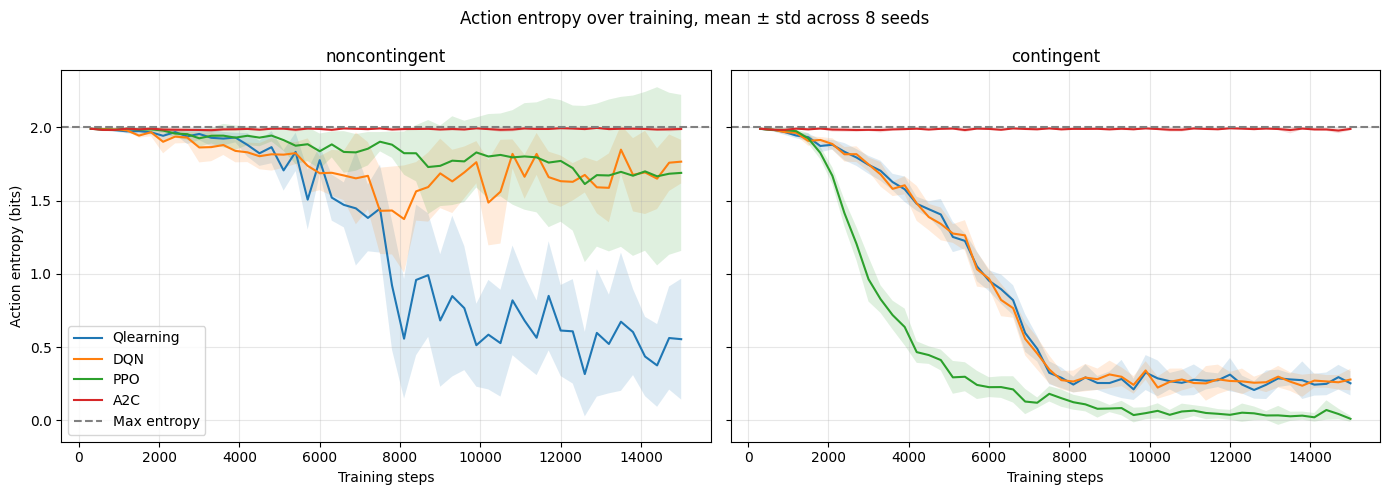

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for algo in ALGOS:
    for ax, condition in zip(axes, CONDITIONS):
        ts, mean, std = entropy_matrix(results_A[(algo, condition)])
        ax.plot(ts, mean, label=algo)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)

for ax, condition in zip(axes, CONDITIONS):
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(f"{condition}")
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Action entropy over training, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for algo in ALGOS:
    for condition in CONDITIONS:
        s = summarize(results_A[(algo, condition)])
        rows.append({
            "Algorithm": algo, "Condition": condition,
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_A = pd.DataFrame(rows)
df_A

,Algorithm,Condition,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,noncontingent,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,contingent,0.26 ± 0.04,1.00 ± 0.00,11764.1 ± 29.8
2,DQN,noncontingent,1.71 ± 0.13,0.42 ± 0.09,14.2 ± 2.6
3,DQN,contingent,0.26 ± 0.02,1.00 ± 0.00,11778.2 ± 54.2
4,PPO,noncontingent,1.68 ± 0.56,0.50 ± 0.18,12.8 ± 13.0
5,PPO,contingent,0.04 ± 0.02,1.00 ± 0.00,13106.8 ± 44.9
6,A2C,noncontingent,1.99 ± 0.00,0.36 ± 0.05,6.5 ± 0.9
7,A2C,contingent,1.99 ± 0.01,1.00 ± 0.00,3860.4 ± 76.8


In [ ]:
print("=== Tier A statistical tests ===\n")

print("Noncontingent vs. contingent, per algorithm (is the 'ritual' as strong as real learning?):")
for algo in ALGOS:
    s_nc = summarize(results_A[(algo, "noncontingent")])
    s_c = summarize(results_A[(algo, "contingent")])
    print(f" {algo}:")
    compare_two(s_nc["final_entropy_vals"], s_c["final_entropy_vals"],
                "noncontingent", "contingent", "final_entropy", tier="A", context=algo)

print("\nAcross algorithms, noncontingent condition only (is superstition algorithm-dependent?):")
final_ent_by_algo = [summarize(results_A[(a, "noncontingent")])["final_entropy_vals"] for a in ALGOS]
compare_many(final_ent_by_algo, ALGOS, "final_entropy", tier="A", context="noncontingent")

ritual_streak_by_algo = [summarize(results_A[(a, "noncontingent")])["ritual_streak_vals"] for a in ALGOS]
compare_many(ritual_streak_by_algo, ALGOS, "ritual_streak", tier="A", context="noncontingent")

=== Tier A statistical tests ===

Noncontingent vs. contingent, per algorithm (is the 'ritual' as strong as real learning?):
 Qlearning:
  final_entropy | Qlearning noncontingent vs contingent: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=2.49, diff=0.243 [95% CI 0.157, 0.333]
 DQN:
  final_entropy | DQN noncontingent vs contingent: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=14.13, diff=1.446 [95% CI 1.346, 1.530]
 PPO:
  final_entropy | PPO noncontingent vs contingent: Mann-Whitney p=0.0009 (uncorrected), Cohen's d=3.92, diff=1.646 [95% CI 1.225, 1.933]
 A2C:
  final_entropy | A2C noncontingent vs contingent: Mann-Whitney p=0.6454 (uncorrected), Cohen's d=0.34, diff=0.002 [95% CI -0.003, 0.007]

Across algorithms, noncontingent condition only (is superstition algorithm-dependent?):
  final_entropy | noncontingent Kruskal-Wallis across ['Qlearning', 'DQN', 'PPO', 'A2C']: p=0.0000 (uncorrected), epsilon^2=0.769
  ritual_streak | noncontingent Kruskal-Wallis across ['Qlearning', 'D

(np.float64(1.1149030346907578e-05), 0.8098598044641212)

### Supplementary S1 -- null baselines and contingent learnability

Three issues this cell addresses:
1. **The headline comparison.** Noncontingent entropy is compared above to the *contingent* control, but a
   contingent agent collapses almost completely, so that comparison cannot show "collapse". The relevant
   reference for fixation is a **uniform-random policy**. Below, each algorithm's per-seed noncontingent values
   are tested against the simulated null mean (one-sample Wilcoxon).
2. **Chance level for ritual strength.** The modal fraction over `K=30` reward events and 4 actions is *not* 0.25
   under random behaviour (the max of a multinomial is biased upward). The null is simulated rather than assumed.
3. **Contingent ritual metrics are tautological.** In the contingent condition reward is only given for the
   target action, so ritual strength/streak are trivially 1.0 / total-reward-count regardless of learning.
   The informative learnability measure there is `target_rate` (chance = 0.25).

In [ ]:
from scipy.stats import wilcoxon


def null_baseline(interval=INTERVAL, total_steps=TOTAL_STEPS, n_sims=N_NULL_SIMS, seed=777):
    """Simulated behaviour of a uniform-random policy: ritual strength/streak over total_steps//interval
    reward events, and the per-seed 'final entropy' statistic (mean of 5 independent windows of size WINDOW)."""
    rng = np.random.default_rng(seed)
    n_rewards = total_steps // interval
    strengths, streaks, ents = [], [], []
    for _ in range(n_sims):
        rm = ritual_metrics(rng.integers(0, N_ACTIONS, n_rewards).tolist())
        strengths.append(rm["ritual_strength"]); streaks.append(rm["ritual_streak"])
        wins = rng.integers(0, N_ACTIONS, (5, WINDOW))
        ents.append(np.mean([compute_entropy(w, N_ACTIONS) for w in wins]))
    return {
        "strength_mean": float(np.mean(strengths)), "strength_p95": float(np.percentile(strengths, 95)),
        "streak_mean": float(np.mean(streaks)), "streak_p95": float(np.percentile(streaks, 95)),
        "entropy_mean": float(np.mean(ents)), "entropy_p05": float(np.percentile(ents, 5)),
    }


NULL = null_baseline()
print("Uniform-random-policy null (I=%d, %d steps, %d sims):" % (INTERVAL, TOTAL_STEPS, N_NULL_SIMS))
for k_, v_ in NULL.items():
    print(f"  {k_:>14s}: {v_:.3f}")


def compare_one_sample(vals, mu0, metric_name, family, tier, context):
    """One-sample Wilcoxon signed-rank test of per-seed values against a fixed null value mu0."""
    diffs = np.asarray(vals, dtype=float) - mu0
    try:
        stat, p = wilcoxon(diffs, alternative="two-sided")
    except ValueError:   # all differences zero
        stat, p = float("nan"), 1.0
    _log_test({"tier": tier, "context": context, "test": "wilcoxon_1sample", "family": family,
               "comparison": f"{context} vs null({mu0:.3f})", "metric": metric_name,
               "p_raw": p, "stat": stat, "diff": float(np.mean(diffs)), "n": len(vals), "mu0": mu0})
    print(f"  {metric_name} | {context} vs uniform-random null {mu0:.3f}: Wilcoxon p={p:.4f} (uncorrected), "
          f"mean diff={np.mean(diffs):+.3f}")


print("\nNoncontingent (fixed-interval) vs the uniform-random null:")
rows = []
for algo in ALGOS:
    s = summarize(results_A[(algo, "noncontingent")])
    compare_one_sample(s["final_entropy_vals"], NULL["entropy_mean"], "final_entropy",
                       "supp_vs_null_entropy", "S1", algo)
    compare_one_sample(s["ritual_strength_vals"], NULL["strength_mean"], "ritual_strength",
                       "supp_vs_null_ritual", "S1", algo)
    rows.append({
        "Algorithm": algo,
        "Final entropy": f"{s['final_entropy_mean']:.2f}",
        "Null entropy (mean)": f"{NULL['entropy_mean']:.2f}",
        "Ritual strength": f"{s['ritual_strength_mean']:.2f}",
        "Null strength (mean / 95th pct)": f"{NULL['strength_mean']:.2f} / {NULL['strength_p95']:.2f}",
        "Seeds above null 95th pct (strength)": int((s["ritual_strength_vals"] > NULL["strength_p95"]).sum()),
        "Ritual streak": f"{s['ritual_streak_mean']:.1f}",
        "Null streak (mean / 95th pct)": f"{NULL['streak_mean']:.1f} / {NULL['streak_p95']:.1f}",
    })
df_S1_null = pd.DataFrame(rows)

print("\nContingent control learnability (target_rate = fraction of final window on the target action; chance = 0.25):")
rows_tr = []
for algo in ALGOS:
    tr = target_rate_vals(results_A[(algo, "contingent")])
    rows_tr.append({"Algorithm": algo, "Target-action rate": f"{tr.mean():.2f} \u00b1 {tr.std():.2f}"})
df_S1_target = pd.DataFrame(rows_tr)
print(df_S1_target.to_string(index=False))
df_S1_null

Uniform-random-policy null (I=10, 15000 steps, 2000 sims):
   strength_mean: 0.346
    strength_p95: 0.433
     streak_mean: 5.979
      streak_p95: 8.000
    entropy_mean: 1.989
     entropy_p05: 1.982

Noncontingent (fixed-interval) vs the uniform-random null:
  final_entropy | Qlearning vs uniform-random null 1.989: Wilcoxon p=0.0078 (uncorrected), mean diff=-1.482
  ritual_strength | Qlearning vs uniform-random null 0.346: Wilcoxon p=0.0078 (uncorrected), mean diff=+0.483
  final_entropy | DQN vs uniform-random null 1.989: Wilcoxon p=0.0078 (uncorrected), mean diff=-0.280
  ritual_strength | DQN vs uniform-random null 0.346: Wilcoxon p=0.0312 (uncorrected), mean diff=+0.079
  final_entropy | PPO vs uniform-random null 1.989: Wilcoxon p=0.0078 (uncorrected), mean diff=-0.307
  ritual_strength | PPO vs uniform-random null 0.346: Wilcoxon p=0.0078 (uncorrected), mean diff=+0.150
  final_entropy | A2C vs uniform-random null 1.989: Wilcoxon p=1.0000 (uncorrected), mean diff=-0.000
  rit

,Algorithm,Final entropy,Null entropy (mean),Ritual strength,Null strength (mean / 95th pct),Seeds above null 95th pct (strength),Ritual streak,Null streak (mean / 95th pct)
0,Qlearning,0.51,1.99,0.83,0.35 / 0.43,8,90.2,6.0 / 8.0
1,DQN,1.71,1.99,0.42,0.35 / 0.43,2,14.2,6.0 / 8.0
2,PPO,1.68,1.99,0.50,0.35 / 0.43,3,12.8,6.0 / 8.0
3,A2C,1.99,1.99,0.36,0.35 / 0.43,0,6.5,6.0 / 8.0


## Tier B — Reward Schedule Sensitivity

Does the *type* of noncontingent schedule (fixed / variable / random interval)
change how strongly a ritual forms? Tested on Q-learning and PPO (the pilot's two
core algorithms) to keep runtime manageable.

In [ ]:
SCHEDULES = ["fixed", "variable", "random"]
TIER_B_ALGOS = ["Qlearning", "PPO"]

PPO_EXTRA_SEEDS = range(N_SEEDS, N_SEEDS_PPO_EXT)

results_B = {}
for algo in TIER_B_ALGOS:
    for sched in SCHEDULES:
        if algo == "PPO":
            if sched == "fixed":
                base = results_A[("PPO", "noncontingent")]
            else:
                base = run_multiseed("PPO", n_seeds=N_SEEDS, reward_mode="noncontingent",
                                     schedule_type=sched, curiosity_bonus=False, total_steps=TOTAL_STEPS)
            extra = run_multiseed("PPO", seeds=PPO_EXTRA_SEEDS, reward_mode="noncontingent",
                                  schedule_type=sched, curiosity_bonus=False, total_steps=TOTAL_STEPS)
            results_B[(algo, sched)] = list(base) + list(extra)
        else:
            results_B[(algo, sched)] = run_multiseed(
                algo, n_seeds=N_SEEDS, reward_mode="noncontingent",
                schedule_type=sched, curiosity_bonus=False, total_steps=TOTAL_STEPS
            )
        print(f"Done: {algo:>10s} / {sched}  (n={len(results_B[(algo, sched)])})")

Done:  Qlearning / fixed  (n=8)
Done:  Qlearning / variable  (n=8)
Done:  Qlearning / random  (n=8)
Done:        PPO / fixed  (n=24)
Done:        PPO / variable  (n=24)
Done:        PPO / random  (n=24)


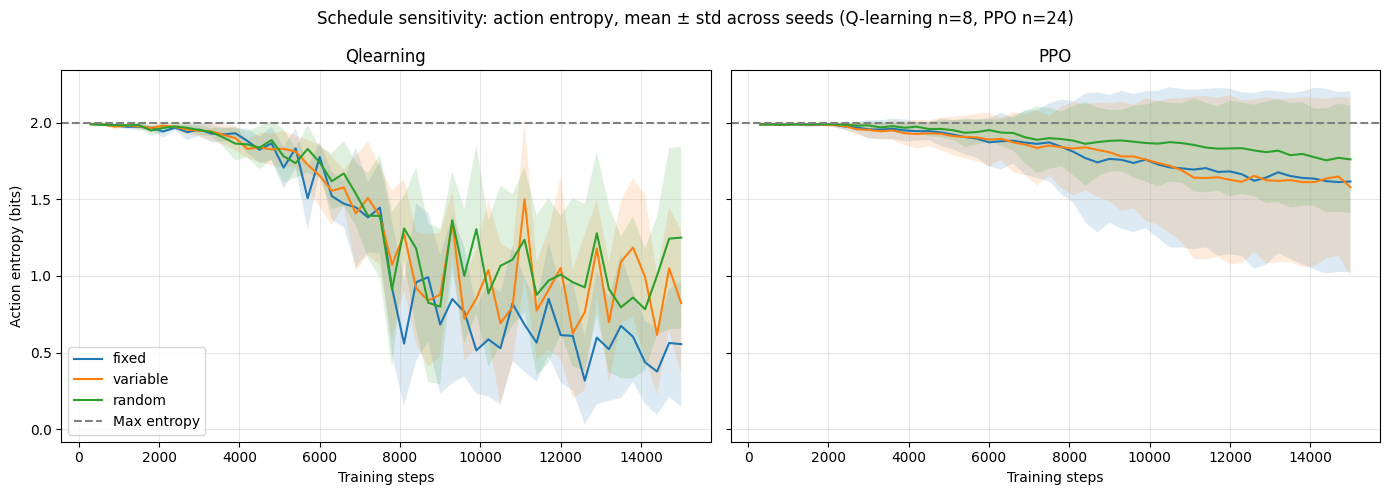

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, algo in zip(axes, TIER_B_ALGOS):
    for sched in SCHEDULES:
        ts, mean, std = entropy_matrix(results_B[(algo, sched)])
        ax.plot(ts, mean, label=sched)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(algo)
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Schedule sensitivity: action entropy, mean \u00b1 std across seeds (Q-learning n={N_SEEDS}, PPO n={N_SEEDS_PPO_EXT})")
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for algo in TIER_B_ALGOS:
    for sched in SCHEDULES:
        s = summarize(results_B[(algo, sched)])
        rows.append({
            "Algorithm": algo, "Schedule": sched,
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_B = pd.DataFrame(rows)
df_B

,Algorithm,Schedule,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,fixed,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,variable,0.93 ± 0.12,0.73 ± 0.18,68.8 ± 17.0
2,Qlearning,random,1.03 ± 0.19,0.61 ± 0.20,55.5 ± 15.9
3,PPO,fixed,1.62 ± 0.58,0.50 ± 0.22,19.2 ± 34.3
4,PPO,variable,1.62 ± 0.54,0.49 ± 0.22,13.5 ± 17.2
5,PPO,random,1.77 ± 0.33,0.46 ± 0.15,8.7 ± 4.7


In [ ]:
print("=== Tier B statistical tests: does schedule type matter? ===\n")
for algo in TIER_B_ALGOS:
    print(f"{algo}:")
    vals = [summarize(results_B[(algo, s)])["final_entropy_vals"] for s in SCHEDULES]
    compare_many(vals, SCHEDULES, "final_entropy", tier="B", context=algo)
    vals_rs = [summarize(results_B[(algo, s)])["ritual_strength_vals"] for s in SCHEDULES]
    compare_many(vals_rs, SCHEDULES, "ritual_strength", tier="B", context=algo)
    if algo == "PPO":
        # Descriptive sensitivity: the same tests on the original 8 seeds only (NOT logged / not corrected).
        print(f"  -- PPO restricted to the original seeds 0..{N_SEEDS-1} (for comparison with v2; not logged) --")
        v8 = [v[:N_SEEDS] for v in vals]
        compare_many(v8, SCHEDULES, "final_entropy", tier="B", context="PPO_n8_only", family="final_entropy", log=False)
        v8r = [v[:N_SEEDS] for v in vals_rs]
        compare_many(v8r, SCHEDULES, "ritual_strength", tier="B", context="PPO_n8_only", family="ritual_strength", log=False)
    print()

=== Tier B statistical tests: does schedule type matter? ===

Qlearning:
  final_entropy | Qlearning Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.0004 (uncorrected), epsilon^2=0.655
  ritual_strength | Qlearning Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.0995 (uncorrected), epsilon^2=0.125

PPO:
  final_entropy | PPO Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.8878 (uncorrected), epsilon^2=-0.026
  ritual_strength | PPO Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.7594 (uncorrected), epsilon^2=-0.021
  -- PPO restricted to the original seeds 0..7 (for comparison with v2; not logged) --
  final_entropy | PPO_n8_only Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.5813 (uncorrected), epsilon^2=-0.044  [not logged]
  ritual_strength | PPO_n8_only Kruskal-Wallis across ['fixed', 'variable', 'random']: p=0.1502 (uncorrected), epsilon^2=0.085  [not logged]



### Supplementary S2 -- Tier B post-hoc pairwise tests

The Kruskal-Wallis omnibus test in Tier B cannot, on its own, show *which* schedules differ (e.g. the claim that
"fixed differs from variable and random"). These pairwise Mann-Whitney tests on final entropy are logged in their
own supplementary family so they do not change the confirmatory m.

In [ ]:
from itertools import combinations

print("=== Tier B post-hoc pairwise comparisons (final entropy) ===\n")
for algo in TIER_B_ALGOS:
    print(f"{algo}:")
    for s1, s2 in combinations(SCHEDULES, 2):
        compare_two(summarize(results_B[(algo, s1)])["final_entropy_vals"],
                    summarize(results_B[(algo, s2)])["final_entropy_vals"],
                    s1, s2, "final_entropy", family="supp_tierB_pairwise_entropy",
                    tier="B-post", context=algo)
    print()

=== Tier B post-hoc pairwise comparisons (final entropy) ===

Qlearning:
  final_entropy | Qlearning fixed vs variable: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=-3.27, diff=-0.427 [95% CI -0.546, -0.309]
  final_entropy | Qlearning fixed vs random: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=-3.00, diff=-0.521 [95% CI -0.679, -0.361]
  final_entropy | Qlearning variable vs random: Mann-Whitney p=0.3823 (uncorrected), Cohen's d=-0.55, diff=-0.094 [95% CI -0.251, 0.057]

PPO:
  final_entropy | PPO fixed vs variable: Mann-Whitney p=0.6876 (uncorrected), Cohen's d=0.01, diff=0.007 [95% CI -0.309, 0.324]
  final_entropy | PPO fixed vs random: Mann-Whitney p=0.7029 (uncorrected), Cohen's d=-0.30, diff=-0.147 [95% CI -0.421, 0.109]
  final_entropy | PPO variable vs random: Mann-Whitney p=0.8286 (uncorrected), Cohen's d=-0.34, diff=-0.154 [95% CI -0.416, 0.091]



## Tier C — Curiosity-Driven Exploration (Moderator Test)

Does adding a count-based exploration bonus dilute the ritual (broader coverage,
per the "Noisy TV" chapter's mitigation angle) or compound it (a second source of
spurious reward)? Tested on Q-learning and PPO, fixed-interval noncontingent
condition only.

In [ ]:
results_C = {}
for algo in TIER_B_ALGOS:
    for curiosity in [False, True]:
        if algo == "PPO":
            if not curiosity:
                # identical configuration to Tier B PPO/fixed (n = N_SEEDS_PPO_EXT) -- reused, not rerun
                results_C[(algo, curiosity)] = results_B[("PPO", "fixed")]
            else:
                results_C[(algo, curiosity)] = run_multiseed(
                    "PPO", n_seeds=N_SEEDS_PPO_EXT, reward_mode="noncontingent",
                    schedule_type="fixed", curiosity_bonus=True, total_steps=TOTAL_STEPS)
        else:
            results_C[(algo, curiosity)] = run_multiseed(
                algo, n_seeds=N_SEEDS, reward_mode="noncontingent",
                schedule_type="fixed", curiosity_bonus=curiosity, total_steps=TOTAL_STEPS
            )
        label = "curiosity ON" if curiosity else "curiosity OFF"
        print(f"Done: {algo:>10s} / {label}  (n={len(results_C[(algo, curiosity)])})")

Done:  Qlearning / curiosity OFF  (n=8)
Done:  Qlearning / curiosity ON  (n=8)
Done:        PPO / curiosity OFF  (n=24)
Done:        PPO / curiosity ON  (n=24)


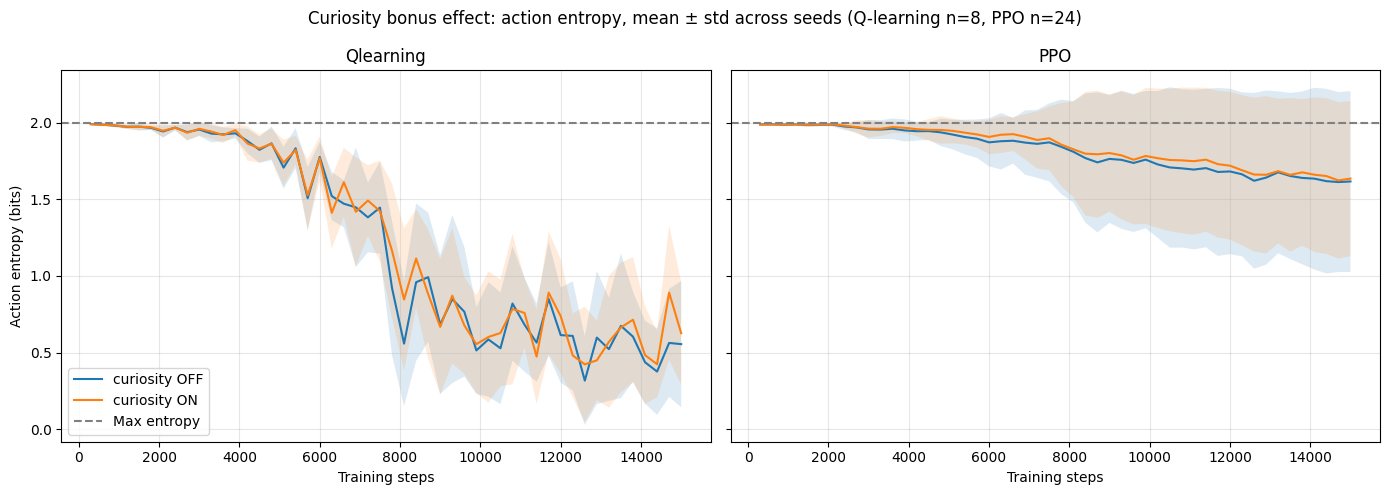

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, algo in zip(axes, TIER_B_ALGOS):
    for curiosity, label in [(False, "curiosity OFF"), (True, "curiosity ON")]:
        ts, mean, std = entropy_matrix(results_C[(algo, curiosity)])
        ax.plot(ts, mean, label=label)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(algo)
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)")
axes[0].legend()
fig.suptitle(f"Curiosity bonus effect: action entropy, mean \u00b1 std across seeds (Q-learning n={N_SEEDS}, PPO n={N_SEEDS_PPO_EXT})")
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for algo in TIER_B_ALGOS:
    for curiosity in [False, True]:
        s = summarize(results_C[(algo, curiosity)])
        rows.append({
            "Algorithm": algo, "Curiosity": "ON" if curiosity else "OFF",
            "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
            "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
            "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
        })
df_C = pd.DataFrame(rows)
df_C

,Algorithm,Curiosity,Final Entropy,Ritual Strength,Ritual Streak
0,Qlearning,OFF,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
1,Qlearning,ON,0.63 ± 0.10,0.84 ± 0.15,80.2 ± 19.1
2,PPO,OFF,1.62 ± 0.58,0.50 ± 0.22,19.2 ± 34.3
3,PPO,ON,1.65 ± 0.50,0.50 ± 0.19,17.3 ± 33.5


In [ ]:
print("=== Tier C statistical tests: does curiosity change the ritual? ===\n")
for algo in TIER_B_ALGOS:
    s_off = summarize(results_C[(algo, False)])
    s_on = summarize(results_C[(algo, True)])
    print(f"{algo}:")
    compare_two(s_off["final_entropy_vals"], s_on["final_entropy_vals"],
                "curiosity OFF", "curiosity ON", "final_entropy", tier="C", context=algo)
    compare_two(s_off["ritual_strength_vals"], s_on["ritual_strength_vals"],
                "curiosity OFF", "curiosity ON", "ritual_strength", tier="C", context=algo)
    if algo == "PPO":
        print(f"  -- PPO restricted to the original seeds 0..{N_SEEDS-1} (for comparison with v2; not logged) --")
        compare_two(s_off["final_entropy_vals"][:N_SEEDS], s_on["final_entropy_vals"][:N_SEEDS],
                    "curiosity OFF", "curiosity ON", "final_entropy", tier="C", context="PPO_n8_only",
                    family="final_entropy", log=False)
        compare_two(s_off["ritual_strength_vals"][:N_SEEDS], s_on["ritual_strength_vals"][:N_SEEDS],
                    "curiosity OFF", "curiosity ON", "ritual_strength", tier="C", context="PPO_n8_only",
                    family="ritual_strength", log=False)
    print()

=== Tier C statistical tests: does curiosity change the ritual? ===

Qlearning:
  final_entropy | Qlearning curiosity OFF vs curiosity ON: Mann-Whitney p=0.0499 (uncorrected), Cohen's d=-1.02, diff=-0.121 [95% CI -0.228, -0.008]
  ritual_strength | Qlearning curiosity OFF vs curiosity ON: Mann-Whitney p=1.0000 (uncorrected), Cohen's d=-0.07, diff=-0.013 [95% CI -0.167, 0.146]

PPO:
  final_entropy | PPO curiosity OFF vs curiosity ON: Mann-Whitney p=0.7966 (uncorrected), Cohen's d=-0.05, diff=-0.025 [95% CI -0.339, 0.273]
  ritual_strength | PPO curiosity OFF vs curiosity ON: Mann-Whitney p=0.6552 (uncorrected), Cohen's d=0.01, diff=0.001 [95% CI -0.117, 0.118]
  -- PPO restricted to the original seeds 0..7 (for comparison with v2; not logged) --
  final_entropy | PPO_n8_only curiosity OFF vs curiosity ON: Mann-Whitney p=0.7984 (uncorrected), Cohen's d=-0.05, diff=-0.025 [95% CI -0.520, 0.419]  [not logged]
  ritual_strength | PPO_n8_only curiosity OFF vs curiosity ON: Mann-Whitney p=1.

### Supplementary S3 -- power / minimum detectable effect and equivalence for the PPO nulls

A non-significant result at n=8 per group can only rule out large effects. This cell (a) simulates the minimum
detectable standardized effect (Mann-Whitney, 80% power, uncorrected alpha=0.05) at the original and extended
sample sizes, converted to bits using PPO's observed SD, and (b) reports a 90% bootstrap CI on each PPO
difference against the equivalence margin `EQUIV_MARGIN` (a TOST-style check: if the 90% CI lies inside
+/- margin the difference is "equivalent to zero" at that margin). These are descriptive and are not entered
into the Holm tests.

In [ ]:
def mw_power(n, d, n_sims=1000, alpha=ALPHA, seed=2024):
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(n_sims):
        a = rng.normal(0.0, 1.0, n); b = rng.normal(d, 1.0, n)
        if mannwhitneyu(a, b, alternative="two-sided")[1] < alpha:
            hits += 1
    return hits / n_sims


def minimum_detectable_d(n, target=0.8, grid=np.arange(0.6, 3.01, 0.1)):
    for d in grid:
        if mw_power(n, float(d)) >= target:
            return float(round(d, 2))
    return float("nan")


ppo_sd = float(np.mean([summarize(results_B[("PPO", s)])["final_entropy_std"] for s in SCHEDULES]))
power_summary = {"ppo_final_entropy_sd": ppo_sd, "equiv_margin_bits": EQUIV_MARGIN}
print(f"PPO observed final-entropy SD (mean over schedules): {ppo_sd:.3f} bits")
for n_ in (N_SEEDS, N_SEEDS_PPO_EXT):
    d_min = minimum_detectable_d(n_)
    power_summary[f"mde_d_n{n_}"] = d_min
    power_summary[f"mde_bits_n{n_}"] = d_min * ppo_sd
    print(f"  n={n_:>2d}/group: minimum detectable effect (80% power, alpha=0.05 uncorrected) "
          f"d~{d_min:.1f}  =>  ~{d_min * ppo_sd:.2f} bits")

print(f"\nEquivalence check on PPO final entropy (90% bootstrap CI vs +/-{EQUIV_MARGIN} bits):")
eq_rows = []
pairs = [(f"{s1} vs {s2}", summarize(results_B[("PPO", s1)])["final_entropy_vals"],
          summarize(results_B[("PPO", s2)])["final_entropy_vals"]) for s1, s2 in combinations(SCHEDULES, 2)]
pairs.append(("curiosity OFF vs ON", summarize(results_C[("PPO", False)])["final_entropy_vals"],
              summarize(results_C[("PPO", True)])["final_entropy_vals"]))
for label, a, b in pairs:
    diff, lo, hi = bootstrap_diff_ci(a, b, ci=0.90)
    equiv = (lo > -EQUIV_MARGIN) and (hi < EQUIV_MARGIN)
    eq_rows.append({"PPO comparison": label, "diff (bits)": round(diff, 3),
                    "90% CI": f"[{lo:.3f}, {hi:.3f}]", f"within +/-{EQUIV_MARGIN}?": equiv})
df_equiv = pd.DataFrame(eq_rows)
df_equiv

PPO observed final-entropy SD (mean over schedules): 0.484 bits
  n= 8/group: minimum detectable effect (80% power, alpha=0.05 uncorrected) d~1.6  =>  ~0.78 bits
  n=24/group: minimum detectable effect (80% power, alpha=0.05 uncorrected) d~0.9  =>  ~0.44 bits

Equivalence check on PPO final entropy (90% bootstrap CI vs +/-0.5 bits):


,PPO comparison,diff (bits),90% CI,within +/-0.5?
0,fixed vs variable,0.007,"[-0.267, 0.273]",True
1,fixed vs random,-0.147,"[-0.378, 0.073]",True
2,variable vs random,-0.154,"[-0.368, 0.054]",True
3,curiosity OFF vs ON,-0.025,"[-0.280, 0.227]",True


## 6. Tier D — Interval-Length Sensitivity Check (I = 5, 10, 20)

**Recommended #1.** Tier B's central claim is that Q-learning's fixed-interval
ritual is stronger than its variable/random-interval ritual because a *fixed
temporal phase* lets a bootstrapped update lock onto it — not because
noncontingency alone is sufficient. If that mechanism is right, and not an
artifact of the specific interval length `I=10` used everywhere else in this
study, the same qualitative pattern (entropy collapse, high ritual strength)
should hold at other interval lengths too.

This tier reruns Q-learning under the **fixed-interval** schedule at `I=5` and
`I=20`, and reuses the existing `I=10` result from Tier B directly (same
training code, same seeds, same everything else) rather than rerunning it, so
the three-way comparison is exactly apples-to-apples.

Restricted to **Q-learning only** (the algorithm with the clear schedule-
sensitivity effect in Tier B) to keep runtime manageable — PPO showed
essentially no schedule sensitivity in Tier B, so an interval sweep on PPO is a
lower-priority follow-up rather than a check on this study's central claim.

**Statistical note:** these tests are logged under their own family
(`interval_sensitivity_entropy` / `interval_sensitivity_ritual`), separate from
the Tier A-C confirmatory families, since this is a post-hoc robustness check
on a single parameter added after seeing Tier B's result, not part of the
original design — see the pre-registration note above and Section 7 below.


In [ ]:
INTERVAL_SWEEP = [5, INTERVAL, 20]  # INTERVAL == 10; included via the Tier B reuse below

results_D = {INTERVAL: results_B[("Qlearning", "fixed")]}  # reuse Tier B's I=10 run verbatim
for I_val in [5, 20]:
    results_D[I_val] = run_multiseed(
        "Qlearning", n_seeds=N_SEEDS, reward_mode="noncontingent",
        schedule_type="fixed", curiosity_bonus=False, total_steps=TOTAL_STEPS,
        interval=I_val,
    )
    print(f"Done: Qlearning / I={I_val}")


Done: Qlearning / I=5
Done: Qlearning / I=20


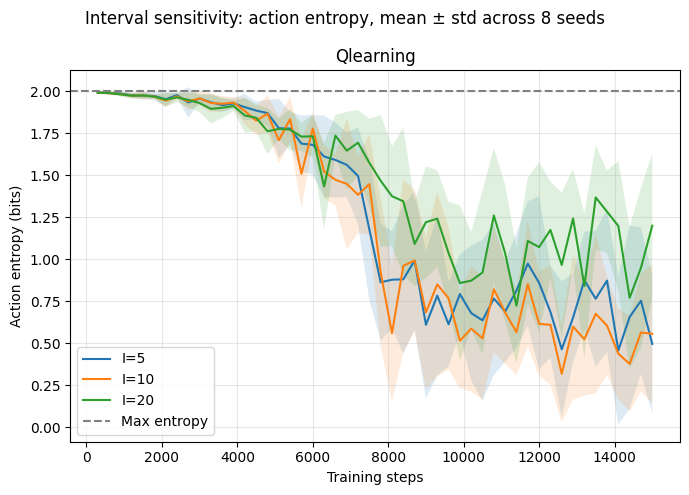

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for I_val in INTERVAL_SWEEP:
    ts, mean, std = entropy_matrix(results_D[I_val])
    ax.plot(ts, mean, label=f"I={I_val}")
    ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
ax.set_title("Qlearning")
ax.set_xlabel("Training steps")
ax.set_ylabel("Action entropy (bits)")
ax.grid(alpha=0.3)
ax.legend()
fig.suptitle(f"Interval sensitivity: action entropy, mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout()
plt.show()


In [ ]:
rows = []
for I_val in INTERVAL_SWEEP:
    s = summarize(results_D[I_val])
    rows.append({
        "Interval (I)": I_val,
        "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
        "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
        "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}",
    })
df_D = pd.DataFrame(rows)
df_D


,Interval (I),Final Entropy,Ritual Strength,Ritual Streak
0,5,0.65 ± 0.15,0.95 ± 0.10,120.0 ± 29.9
1,10,0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4
2,20,1.08 ± 0.20,0.60 ± 0.16,23.5 ± 3.5


In [ ]:
print("=== Tier D statistical tests: does interval length change the ritual? ===\n")
print("Qlearning:")
vals = [summarize(results_D[I_val])["final_entropy_vals"] for I_val in INTERVAL_SWEEP]
compare_many(vals, [f"I={v}" for v in INTERVAL_SWEEP], "final_entropy",
             family="interval_sensitivity_entropy", tier="D", context="Qlearning")
vals_rs = [summarize(results_D[I_val])["ritual_strength_vals"] for I_val in INTERVAL_SWEEP]
compare_many(vals_rs, [f"I={v}" for v in INTERVAL_SWEEP], "ritual_strength",
             family="interval_sensitivity_ritual", tier="D", context="Qlearning")

=== Tier D statistical tests: does interval length change the ritual? ===

Qlearning:
  final_entropy | Qlearning Kruskal-Wallis across ['I=5', 'I=10', 'I=20']: p=0.0006 (uncorrected), epsilon^2=0.616
  ritual_strength | Qlearning Kruskal-Wallis across ['I=5', 'I=10', 'I=20']: p=0.0018 (uncorrected), epsilon^2=0.507


(np.float64(0.001797683883128138), 0.5067863023071828)

### Supplementary S4 -- Tier D2: schedule x interval (does the fixed-vs-variable/random gap hold at I = 5 and 20?)

Tier D varies the interval length *within* the fixed schedule only, so it cannot show that the
schedule-sensitivity result is robust to interval length (and shorter intervals also mean more reward events
within the fixed training budget). This optional check runs Q-learning under the variable and random schedules
at I = 5 and 20 and compares each to fixed at the same I (I = 10 comes from Tier B). Controlled by
`RUN_TIER_D_SCHEDULES`. Tests go in their own supplementary families.

In [ ]:
results_D2 = {}   # new runs only; I=10 is taken from Tier B at test time
if RUN_TIER_D_SCHEDULES:
    for I_val in [5, 20]:
        for sched in ["variable", "random"]:
            results_D2[(sched, I_val)] = run_multiseed(
                "Qlearning", n_seeds=N_SEEDS, reward_mode="noncontingent",
                schedule_type=sched, curiosity_bonus=False, total_steps=TOTAL_STEPS, interval=I_val)
            print(f"Done: Qlearning / {sched} / I={I_val}")


def _d2_res(sched, I_val):
    if sched == "fixed":
        return results_D[I_val]
    if I_val == INTERVAL:
        return results_B[("Qlearning", sched)]
    return results_D2[(sched, I_val)]


if RUN_TIER_D_SCHEDULES:
    rows = []
    for I_val in INTERVAL_SWEEP:
        for sched in ["fixed", "variable", "random"]:
            s = summarize(_d2_res(sched, I_val))
            rows.append({"Interval (I)": I_val, "Schedule": sched,
                         "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
                         "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
                         "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}"})
    df_D2 = pd.DataFrame(rows)
    print("\n=== Tier D2 tests: fixed vs variable / random at each interval ===")
    for I_val in INTERVAL_SWEEP:
        for sched in ["variable", "random"]:
            a, b = summarize(_d2_res("fixed", I_val)), summarize(_d2_res(sched, I_val))
            compare_two(a["final_entropy_vals"], b["final_entropy_vals"], "fixed", sched, "final_entropy",
                        family="supp_tierD_schedule_entropy", tier="D2", context=f"Qlearning_I={I_val}")
            compare_two(a["ritual_strength_vals"], b["ritual_strength_vals"], "fixed", sched, "ritual_strength",
                        family="supp_tierD_schedule_ritual", tier="D2", context=f"Qlearning_I={I_val}")
    df_D2

Done: Qlearning / variable / I=5
Done: Qlearning / random / I=5
Done: Qlearning / variable / I=20
Done: Qlearning / random / I=20

=== Tier D2 tests: fixed vs variable / random at each interval ===
  final_entropy | Qlearning_I=5 fixed vs variable: Mann-Whitney p=0.0019 (uncorrected), Cohen's d=-2.07, diff=-0.458 [95% CI -0.654, -0.259]
  ritual_strength | Qlearning_I=5 fixed vs variable: Mann-Whitney p=0.2157 (uncorrected), Cohen's d=0.73, diff=0.129 [95% CI -0.025, 0.296]
  final_entropy | Qlearning_I=5 fixed vs random: Mann-Whitney p=0.0030 (uncorrected), Cohen's d=-2.00, diff=-0.357 [95% CI -0.522, -0.193]
  ritual_strength | Qlearning_I=5 fixed vs random: Mann-Whitney p=0.0543 (uncorrected), Cohen's d=1.02, diff=0.167 [95% CI 0.017, 0.312]
  final_entropy | Qlearning_I=10 fixed vs variable: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=-3.27, diff=-0.427 [95% CI -0.550, -0.308]
  ritual_strength | Qlearning_I=10 fixed vs variable: Mann-Whitney p=0.3159 (uncorrected), Cohen's d=0.

## Tier E -- DQN hyperparameter-sensitivity ablation (professor's point 2)

The DQN-vs-Q-learning difference could reflect the DQN settings rather than any architectural property
(DQN also differs from tabular Q-learning in learning rate and discount: SB3 defaults lr=1e-4, gamma=0.99 vs
alpha=0.1, gamma=0.9). Each variant below changes one thing relative to the main DQN configuration
(`DQN_OVERRIDES`), noncontingent fixed-interval, same seeds:

| variant | change vs main DQN |
|---|---|
| `buffer5000_target100` | `buffer_size=5000`, `target_update_interval=100` |
| `gamma0.9` | `gamma=0.9` (matches tabular Q-learning) |
| `lr1e-3` | `learning_rate=1e-3` |

**Question:** does the *direction* of the effect (DQN ends with higher entropy / weaker ritual than tabular
Q-learning) hold across these variants? Tests are in supplementary families `supp_dqn_ablation_*`.

In [ ]:
DQN_VARIANTS = {
    "buffer5000_target100": dict(buffer_size=5000, target_update_interval=100),
    "gamma0.9": dict(gamma=0.9),
    "lr1e-3": dict(learning_rate=1e-3),
}

results_E = {"main": results_A[("DQN", "noncontingent")]}   # main config reused from Tier A
for name, kw in DQN_VARIANTS.items():
    results_E[name] = run_multiseed(
        "DQN", n_seeds=N_SEEDS, reward_mode="noncontingent", schedule_type="fixed",
        curiosity_bonus=False, total_steps=TOTAL_STEPS, sb3_kwargs=kw)
    print(f"Done: DQN / {name}")

Done: DQN / buffer5000_target100
Done: DQN / gamma0.9
Done: DQN / lr1e-3


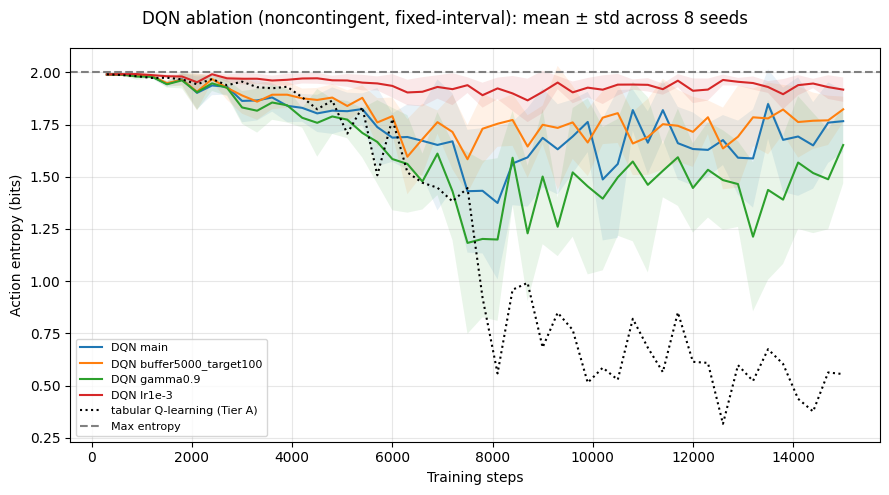

,DQN variant,Final Entropy,Ritual Strength,Ritual Streak
0,main,1.71 ± 0.13,0.42 ± 0.09,14.2 ± 2.6
1,buffer5000_target100,1.79 ± 0.06,0.39 ± 0.08,11.0 ± 2.5
2,gamma0.9,1.52 ± 0.15,0.50 ± 0.12,18.5 ± 3.3
3,lr1e-3,1.93 ± 0.02,0.36 ± 0.04,6.1 ± 0.8
4,"(tabular Q-learning, Tier A)",0.51 ± 0.12,0.83 ± 0.16,90.2 ± 22.4


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for name in results_E:
    ts, mean, std = entropy_matrix(results_E[name])
    ax.plot(ts, mean, label=f"DQN {name}")
    ax.fill_between(ts, mean - std, mean + std, alpha=0.10)
ts, mean, std = entropy_matrix(results_A[("Qlearning", "noncontingent")])
ax.plot(ts, mean, color="black", linestyle=":", label="tabular Q-learning (Tier A)")
ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
ax.set_xlabel("Training steps"); ax.set_ylabel("Action entropy (bits)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f"DQN ablation (noncontingent, fixed-interval): mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout(); plt.show()

rows = []
for name in results_E:
    s = summarize(results_E[name])
    rows.append({"DQN variant": name,
                 "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
                 "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}",
                 "Ritual Streak": f"{s['ritual_streak_mean']:.1f} \u00b1 {s['ritual_streak_std']:.1f}"})
sq = summarize(results_A[("Qlearning", "noncontingent")])
rows.append({"DQN variant": "(tabular Q-learning, Tier A)",
             "Final Entropy": f"{sq['final_entropy_mean']:.2f} \u00b1 {sq['final_entropy_std']:.2f}",
             "Ritual Strength": f"{sq['ritual_strength_mean']:.2f} \u00b1 {sq['ritual_strength_std']:.2f}",
             "Ritual Streak": f"{sq['ritual_streak_mean']:.1f} \u00b1 {sq['ritual_streak_std']:.1f}"})
df_E = pd.DataFrame(rows)
df_E

In [ ]:
print("=== Tier E tests: DQN variants vs main DQN, and vs tabular Q-learning ===\n")
main_s = summarize(results_E["main"])
for name in DQN_VARIANTS:
    s = summarize(results_E[name])
    print(f"{name}:")
    compare_two(s["final_entropy_vals"], main_s["final_entropy_vals"], name, "main_DQN", "final_entropy",
                family="supp_dqn_ablation_entropy", tier="E", context="vs_main_DQN")
    compare_two(s["final_entropy_vals"], sq["final_entropy_vals"], name, "Qlearning", "final_entropy",
                family="supp_dqn_ablation_entropy", tier="E", context="vs_Qlearning")
    compare_two(s["ritual_strength_vals"], main_s["ritual_strength_vals"], name, "main_DQN", "ritual_strength",
                family="supp_dqn_ablation_ritual", tier="E", context="vs_main_DQN")
    compare_two(s["ritual_strength_vals"], sq["ritual_strength_vals"], name, "Qlearning", "ritual_strength",
                family="supp_dqn_ablation_ritual", tier="E", context="vs_Qlearning")
    print()

print("Direction check (does DQN still end with HIGHER entropy and LOWER ritual strength than tabular Q-learning?):")
for name in results_E:
    s = summarize(results_E[name])
    print(f"  {name:>22s}: entropy {s['final_entropy_mean']:.2f} vs {sq['final_entropy_mean']:.2f} "
          f"-> higher: {s['final_entropy_mean'] > sq['final_entropy_mean']};  "
          f"ritual strength {s['ritual_strength_mean']:.2f} vs {sq['ritual_strength_mean']:.2f} "
          f"-> lower: {s['ritual_strength_mean'] < sq['ritual_strength_mean']}")

=== Tier E tests: DQN variants vs main DQN, and vs tabular Q-learning ===

buffer5000_target100:
  final_entropy | vs_main_DQN buffer5000_target100 vs main_DQN: Mann-Whitney p=0.2345 (uncorrected), Cohen's d=0.71, diff=0.080 [95% CI -0.014, 0.189]
  final_entropy | vs_Qlearning buffer5000_target100 vs Qlearning: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=12.14, diff=1.283 [95% CI 1.184, 1.378]
  ritual_strength | vs_main_DQN buffer5000_target100 vs main_DQN: Mann-Whitney p=0.2608 (uncorrected), Cohen's d=-0.42, diff=-0.038 [95% CI -0.121, 0.042]
  ritual_strength | vs_Qlearning buffer5000_target100 vs Qlearning: Mann-Whitney p=0.0013 (uncorrected), Cohen's d=-3.22, diff=-0.442 [95% CI -0.562, -0.308]

gamma0.9:
  final_entropy | vs_main_DQN gamma0.9 vs main_DQN: Mann-Whitney p=0.0379 (uncorrected), Cohen's d=-1.22, diff=-0.186 [95% CI -0.321, -0.043]
  final_entropy | vs_Qlearning gamma0.9 vs Qlearning: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=6.93, diff=1.017 [95% CI 0.880, 

## Tier F -- A2C training-adequacy test (professor's point 4)

The paper attributes A2C's flat ~2.0-bit entropy to under-fitting within the budget. One concrete suspect:
the study sets `n_steps=200` for A2C, so 15,000 steps gives only **75 gradient updates** (PPO gets ~20 per rollout).
Two supplementary conditions, each run noncontingent *and* contingent, 8 seeds:

| variant | n_steps | total steps |
|---|---|---|
| `n5_15k` | 5 (SB3 default; ~3000 updates) | 15,000 |
| `n200_45k` | 200 (as in the study) | 3 x 15,000 |

**Pre-declared criterion:** A2C is considered *able to learn this environment* in a variant if, in the
contingent condition, mean final entropy < 0.5 bits **and** mean `target_rate` > 0.5 (chance = 0.25).
If it can learn but the noncontingent entropy stays near the ceiling, the "A2C is robust to spurious credit
assignment" reading gains support; if it cannot learn in either variant, the training-adequacy explanation
remains untested/unsupported and the claim must be softened.

In [ ]:
A2C_VARIANTS = {
    "n5_15k":   dict(sb3_kwargs=dict(n_steps=5),   total_steps=TOTAL_STEPS),
    "n200_45k": dict(sb3_kwargs=dict(n_steps=200), total_steps=3 * TOTAL_STEPS),
}

results_F = {}
for name, cfg in A2C_VARIANTS.items():
    for condition in CONDITIONS:
        results_F[(name, condition)] = run_multiseed(
            "A2C", n_seeds=N_SEEDS, reward_mode=condition, schedule_type="fixed",
            curiosity_bonus=False, total_steps=cfg["total_steps"], sb3_kwargs=cfg["sb3_kwargs"])
        print(f"Done: A2C / {name} / {condition}")

Done: A2C / n5_15k / noncontingent
Done: A2C / n5_15k / contingent
Done: A2C / n200_45k / noncontingent
Done: A2C / n200_45k / contingent


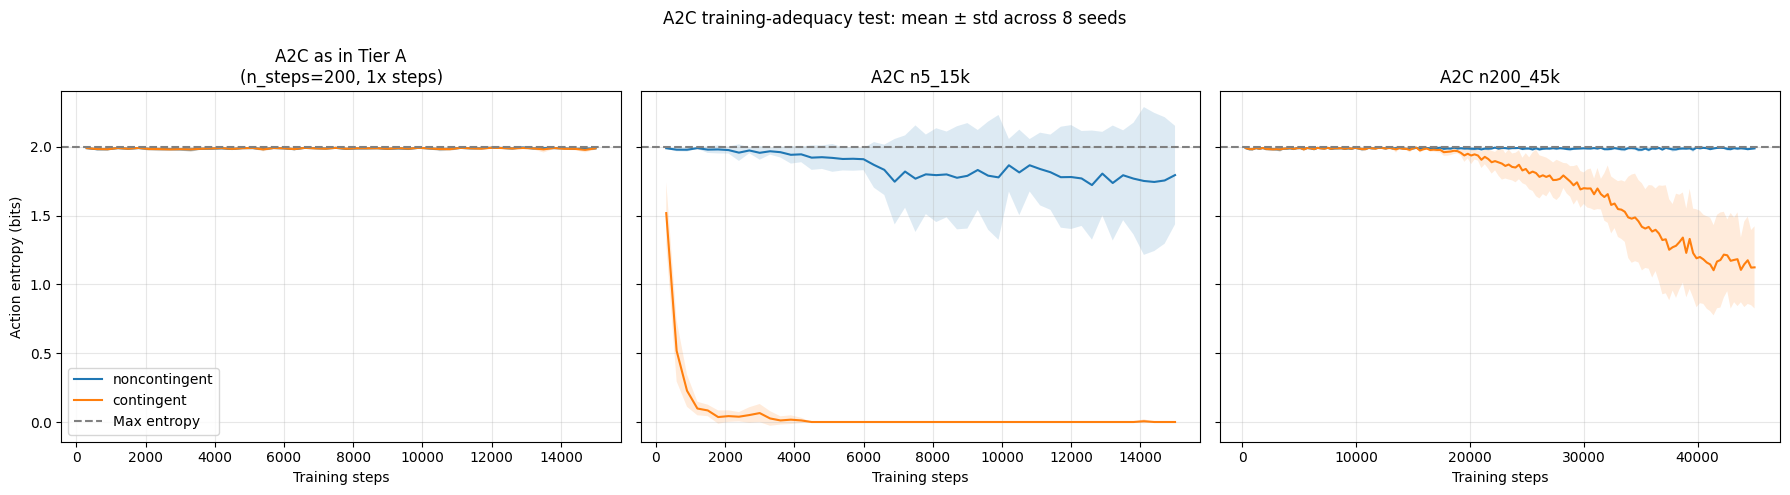

,Variant,Condition,Final Entropy,Ritual Strength,Target rate (chance 0.25),Null ritual strength (mean / 95th pct)
0,"Tier A (n_steps=200, 1x)",noncontingent,1.99 ± 0.00,0.36 ± 0.05,n/a,0.35 / 0.43
1,"Tier A (n_steps=200, 1x)",contingent,1.99 ± 0.01,1.00 ± 0.00,0.26 ± 0.03,NaN
2,n5_15k,noncontingent,1.76 ± 0.45,0.47 ± 0.14,n/a,0.35 / 0.43
3,n5_15k,contingent,0.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,NaN
4,n200_45k,noncontingent,1.99 ± 0.00,0.35 ± 0.04,n/a,0.35 / 0.43
5,n200_45k,contingent,1.14 ± 0.28,1.00 ± 0.00,0.76 ± 0.08,NaN


In [ ]:
panels = [("A2C as in Tier A\n(n_steps=200, 1x steps)", {c: results_A[("A2C", c)] for c in CONDITIONS})]
panels += [(f"A2C {name}", {c: results_F[(name, c)] for c in CONDITIONS}) for name in A2C_VARIANTS]

fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5), sharey=True)
for ax, (title, d) in zip(axes, panels):
    for c, res in d.items():
        ts, mean, std = entropy_matrix(res)
        ax.plot(ts, mean, label=c)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.15)
    ax.axhline(np.log2(N_ACTIONS), color="gray", linestyle="--", label="Max entropy")
    ax.set_title(title); ax.set_xlabel("Training steps"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Action entropy (bits)"); axes[0].legend()
fig.suptitle(f"A2C training-adequacy test: mean \u00b1 std across {N_SEEDS} seeds")
plt.tight_layout(); plt.show()

all_F = {("Tier A (n_steps=200, 1x)", c): results_A[("A2C", c)] for c in CONDITIONS}
all_F.update({(name, c): results_F[(name, c)] for name in A2C_VARIANTS for c in CONDITIONS})
rows = []
for (name, c), res in all_F.items():
    s = summarize(res)
    row = {"Variant": name, "Condition": c,
           "Final Entropy": f"{s['final_entropy_mean']:.2f} \u00b1 {s['final_entropy_std']:.2f}",
           "Ritual Strength": f"{s['ritual_strength_mean']:.2f} \u00b1 {s['ritual_strength_std']:.2f}"}
    if c == "contingent":
        tr = target_rate_vals(res)
        row["Target rate (chance 0.25)"] = f"{tr.mean():.2f} \u00b1 {tr.std():.2f}"
    else:
        row["Target rate (chance 0.25)"] = "n/a"
        row["Null ritual strength (mean / 95th pct)"] = f"{NULL['strength_mean']:.2f} / {NULL['strength_p95']:.2f}"
    rows.append(row)
df_F = pd.DataFrame(rows)
df_F

In [ ]:
print("=== Tier F: can A2C learn the contingent task? (pre-declared criterion) ===")
for name in A2C_VARIANTS:
    sc = summarize(results_F[(name, "contingent")])
    tr = target_rate_vals(results_F[(name, "contingent")])
    learns = (sc["final_entropy_mean"] < 0.5) and (tr.mean() > 0.5)
    print(f"  {name:>9s}: contingent final entropy {sc['final_entropy_mean']:.2f} bits, "
          f"target_rate {tr.mean():.2f}  ->  A2C can learn here: {learns}")

print("\n=== Tier F tests: noncontingent vs contingent entropy, per variant ===")
for name in A2C_VARIANTS:
    nc, ct = summarize(results_F[(name, "noncontingent")]), summarize(results_F[(name, "contingent")])
    compare_two(nc["final_entropy_vals"], ct["final_entropy_vals"], "noncontingent", "contingent",
                "final_entropy", family="supp_a2c_entropy", tier="F", context=name)

=== Tier F: can A2C learn the contingent task? (pre-declared criterion) ===
     n5_15k: contingent final entropy 0.00 bits, target_rate 1.00  ->  A2C can learn here: True
   n200_45k: contingent final entropy 1.14 bits, target_rate 0.76  ->  A2C can learn here: False

=== Tier F tests: noncontingent vs contingent entropy, per variant ===
  final_entropy | n5_15k noncontingent vs contingent: Mann-Whitney p=0.0006 (uncorrected), Cohen's d=5.17, diff=1.763 [95% CI 1.414, 1.961]
  final_entropy | n200_45k noncontingent vs contingent: Mann-Whitney p=0.0002 (uncorrected), Cohen's d=4.05, diff=0.853 [95% CI 0.688, 1.063]


## 7. Multiple-Comparisons Correction

**Must-fix #1.** Every test run above (Tiers A-D) was logged to `TEST_LOG` as it
happened, tagged with a `family`: `final_entropy`, `ritual_strength`, and
`ritual_streak` for the confirmatory design (Tiers A-C), plus
`interval_sensitivity_entropy` / `interval_sensitivity_ritual` for the Tier D
post-hoc check.

Correction is **Holm-Bonferroni**, applied *within* each family rather than
across all tests globally. Family membership follows the metric/question being
tested, not the tier — a claim about entropy and a claim about ritual strength
are different scientific questions, so a ritual-strength test elsewhere in the
study shouldn't inflate the correction burden on an entropy test, or vice
versa. Holm-Bonferroni is used instead of plain Bonferroni because it's
uniformly more powerful while still controlling the family-wise error rate
exactly (no assumption of independence between tests is needed either way).

The cell below prints every test with both its raw and corrected p-value; the
one after it isolates any test whose significance verdict *changes* under
correction, since those are the sentences in Results/Discussion that need to
be rewritten before submission, not just re-numbered.


In [ ]:
correction_df = apply_family_correction(TEST_LOG, alpha=ALPHA)

display_cols = ["design", "family", "m", "holm_rank", "multiplier", "tier", "context", "comparison", "metric",
                "p_raw", "p_corrected", "significant_raw", "significant_corrected"]
trace_df = correction_df[display_cols].sort_values(["design", "family", "holm_rank"]).reset_index(drop=True)

# ---- Traceability check: confirmatory family sizes the paper should state (professor's point 1) ----
EXPECTED_M = {"final_entropy": 9, "ritual_strength": 4, "ritual_streak": 1,
              "interval_sensitivity_entropy": 1, "interval_sensitivity_ritual": 1}
fam_sizes = correction_df.groupby("family").size()
print("Family sizes (m) vs. expected for the confirmatory/post-hoc design:")
for fam, exp in EXPECTED_M.items():
    got = int(fam_sizes.get(fam, 0))
    print(f"  {fam:>30s}: m = {got}  (expected {exp})  {'OK' if got == exp else '<-- MISMATCH, investigate'}")
print("\nTests per design class:")
print(correction_df.groupby("design").size().to_string())
print(f"Total tests logged: {len(correction_df)}")
print("\nTable 4 rows (Tier A within-algorithm final_entropy) -- m and multiplier shown for traceability:")
print(trace_df[(trace_df.tier == "A") & (trace_df.family == "final_entropy") & (trace_df.context.isin(ALGOS))]
      [["context", "m", "holm_rank", "multiplier", "p_raw", "p_corrected"]].to_string(index=False))
trace_df

Family sizes (m) vs. expected for the confirmatory/post-hoc design:
                   final_entropy: m = 9  (expected 9)  OK
                 ritual_strength: m = 4  (expected 4)  OK
                   ritual_streak: m = 1  (expected 1)  OK
    interval_sensitivity_entropy: m = 1  (expected 1)  OK
     interval_sensitivity_ritual: m = 1  (expected 1)  OK

Tests per design class:
design
confirmatory           14
post_hoc_robustness     2
supplementary          40
Total tests logged: 56

Table 4 rows (Tier A within-algorithm final_entropy) -- m and multiplier shown for traceability:
  context  m  holm_rank  multiplier    p_raw  p_corrected
Qlearning  9          2           8 0.000155     0.001243
      DQN  9          3           7 0.000155     0.001243
      PPO  9          5           5 0.000907     0.004534
      A2C  9          7           3 0.645377     1.000000


,design,family,m,holm_rank,multiplier,tier,context,comparison,metric,p_raw,p_corrected,significant_raw,significant_corrected
0,confirmatory,final_entropy,9,1,9,A,noncontingent,Qlearning vs DQN vs PPO vs A2C,final_entropy,0.000019,0.000173,True,True
1,confirmatory,final_entropy,9,2,8,A,Qlearning,noncontingent vs contingent,final_entropy,0.000155,0.001243,True,True
2,confirmatory,final_entropy,9,3,7,A,DQN,noncontingent vs contingent,final_entropy,0.000155,0.001243,True,True
3,confirmatory,final_entropy,9,4,6,B,Qlearning,fixed vs variable vs random,final_entropy,0.000377,0.002264,True,True
4,confirmatory,final_entropy,9,5,5,A,PPO,noncontingent vs contingent,final_entropy,0.000907,0.004534,True,True
5,confirmatory,final_entropy,9,6,4,C,Qlearning,curiosity OFF vs curiosity ON,final_entropy,0.049883,0.199534,True,False
6,confirmatory,final_entropy,9,7,3,A,A2C,noncontingent vs contingent,final_entropy,0.645377,1.000000,False,False
7,confirmatory,final_entropy,9,8,2,C,PPO,curiosity OFF vs curiosity ON,final_entropy,0.796603,1.000000,False,False
8,confirmatory,final_entropy,9,9,1,B,PPO,fixed vs variable vs random,final_entropy,0.887802,1.000000,False,False
9,confirmatory,ritual_streak,1,1,1,A,noncontingent,Qlearning vs DQN vs PPO vs A2C,ritual_streak,0.000011,0.000011,True,True


In [ ]:
flipped = correction_df[correction_df["significant_raw"] & ~correction_df["significant_corrected"]]

print(f"{len(flipped)} test(s) lose significance after Holm-Bonferroni correction "
      f"(alpha={ALPHA}):\n")
if len(flipped) > 0:
    print(flipped[display_cols].to_string(index=False))
    print("\nThese specific claims need softer language (or removal) in Results/"
          "Discussion -- e.g. \'p=0.0499\' becoming non-significant after correction "
          "means a sentence currently claiming a significant effect there is now "
          "overstated.")
else:
    print("None -- every test that was significant at alpha=0.05 before correction "
          "remains significant after Holm-Bonferroni. (Still confirm this holds once "
          "you rerun with real data; this is exactly the kind of result you want to "
          "double-check rather than assume.)")


4 test(s) lose significance after Holm-Bonferroni correction (alpha=0.05):

       design                     family  m  holm_rank  multiplier tier        context                    comparison          metric    p_raw  p_corrected  significant_raw  significant_corrected
supplementary        supp_vs_null_ritual  4          3           2   S1            DQN            DQN vs null(0.346) ritual_strength 0.031250     0.062500             True                  False
 confirmatory              final_entropy  9          6           4    C      Qlearning curiosity OFF vs curiosity ON   final_entropy 0.049883     0.199534             True                  False
supplementary supp_tierD_schedule_ritual  6          1           6   D2 Qlearning_I=10               fixed vs random ritual_strength 0.045201     0.271208             True                  False
supplementary  supp_dqn_ablation_entropy  6          5           2    E    vs_main_DQN          gamma0.9 vs main_DQN   final_entropy 0.037918   

## 8. Raw Per-Seed Data Export

**Must-fix #4 (feeds the CIs above) and recommended #3.** Every number in
Tables 2-4 (and df_D above) is a mean +/- SD over `N_SEEDS` seeds; this cell
dumps the underlying **per-seed** values in long format, plus the complete
entropy/ritual logs for every single run, so a reviewer (or you, in six
months) never has to regenerate anything from scratch to check a number.

Two files get written to `RESULTS_DIR`:
- **`per_seed_summary.csv`** — one row per (tier, algorithm, condition, seed) —
  this *is* the supplementary per-seed table; attach it to the paper as-is or
  reformat it into the appendix.
- **`raw_logs.pkl`** — the full `entropy_log` / `ritual_log` for every run, for
  anyone who wants to replot the trajectories or compute a different statistic
  entirely.
- **`statistical_tests_corrected.csv`** — the corrected-p-value table from
  Section 7, for the same reason.


In [ ]:
import pickle
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


def _tier_to_rows(results_dict, tier_name, key_names):
    """results_dict: {key (tuple or scalar): [per-seed result dicts]}.
    key_names labels the fields of that key for the output columns."""
    rows = []
    for key, seed_results in results_dict.items():
        key_tuple = key if isinstance(key, tuple) else (key,)
        for seed_idx, r in enumerate(seed_results):
            final_e = float(final_entropy_vals([r])[0])
            rm = ritual_metrics(r["ritual_log"])
            row = {
                "tier": tier_name, "seed": seed_idx,
                "final_entropy": final_e,
                "ritual_strength": rm["ritual_strength"],
                "ritual_streak": rm["ritual_streak"],
                "target_rate": (float(np.mean(np.array(r["final_window"]) == 0))
                                if "final_window" in r else float("nan")),
            }
            row.update(dict(zip(key_names, key_tuple)))
            rows.append(row)
    return rows


all_rows = []
all_rows += _tier_to_rows(results_A, "A", ["algorithm", "condition"])
all_rows += _tier_to_rows(results_B, "B", ["algorithm", "schedule"])
all_rows += _tier_to_rows(results_C, "C", ["algorithm", "curiosity"])
all_rows += _tier_to_rows(results_D, "D", ["interval"])
all_rows += _tier_to_rows(results_D2, "D2", ["schedule", "interval"])
all_rows += _tier_to_rows(results_E, "E", ["dqn_variant"])
all_rows += _tier_to_rows(results_F, "F", ["a2c_variant", "condition"])

per_seed_df = pd.DataFrame(all_rows)
per_seed_df.to_csv(RESULTS_DIR / "per_seed_summary.csv", index=False)

with open(RESULTS_DIR / "raw_logs.pkl", "wb") as f:
    pickle.dump({"A": results_A, "B": results_B, "C": results_C, "D": results_D,
                 "D2": results_D2, "E": results_E, "F": results_F}, f)

correction_df.to_csv(RESULTS_DIR / "statistical_tests_corrected.csv", index=False)
trace_df.to_csv(RESULTS_DIR / "test_traceability_table.csv", index=False)
try:
    trace_df.to_latex(RESULTS_DIR / "test_traceability_table.tex", index=False, float_format="%.4f")
except Exception as e:   # to_latex needs jinja2 in recent pandas
    print("LaTeX export skipped:", e)
dqn_hparam_table.to_csv(RESULTS_DIR / "dqn_hyperparameter_overrides.csv", index=False)

import json
with open(RESULTS_DIR / "run_metadata.json", "w") as f:
    json.dump({"stable_baselines3_version": SB3_VERSION, "N_SEEDS": N_SEEDS, "N_SEEDS_PPO_EXT": N_SEEDS_PPO_EXT,
               "TOTAL_STEPS": TOTAL_STEPS, "INTERVAL": INTERVAL, "EQUIV_MARGIN": EQUIV_MARGIN,
               "null_baseline": NULL, "power_summary": power_summary}, f, indent=2, default=float)

print(f"Wrote {len(per_seed_df)} per-seed rows to {RESULTS_DIR / 'per_seed_summary.csv'}")
print(f"Wrote full logs to {RESULTS_DIR / 'raw_logs.pkl'}")
print(f"Wrote corrected test table to {RESULTS_DIR / 'statistical_tests_corrected.csv'}")
print(f"Wrote traceability table to {RESULTS_DIR / 'test_traceability_table.csv'} (+ .tex)")
print(f"Wrote DQN hyperparameter table to {RESULTS_DIR / 'dqn_hyperparameter_overrides.csv'}")
per_seed_df.head()

Wrote 344 per-seed rows to results/per_seed_summary.csv
Wrote full logs to results/raw_logs.pkl
Wrote corrected test table to results/statistical_tests_corrected.csv
Wrote traceability table to results/test_traceability_table.csv (+ .tex)
Wrote DQN hyperparameter table to results/dqn_hyperparameter_overrides.csv


,tier,seed,final_entropy,ritual_strength,ritual_streak,target_rate,algorithm,condition,schedule,curiosity,interval,dqn_variant,a2c_variant
0,A,0,0.441464,0.900000,71,0.865,Qlearning,noncontingent,NaN,NaN,NaN,NaN,NaN
1,A,1,0.543839,0.866667,111,0.010,Qlearning,noncontingent,NaN,NaN,NaN,NaN,NaN
2,A,2,0.345883,0.700000,75,0.060,Qlearning,noncontingent,NaN,NaN,NaN,NaN,NaN
3,A,3,0.393092,0.966667,80,0.985,Qlearning,noncontingent,NaN,NaN,NaN,NaN,NaN
4,A,4,0.402461,1.000000,80,0.000,Qlearning,noncontingent,NaN,NaN,NaN,NaN,NaN


## 9. Packaging for the Public Repository

**Must-fix #3.** "Available on reasonable request" is weaker than it needs to
be, and costs nothing to fix now rather than when a reviewer asks. This cell
zips everything a reviewer needs to reproduce the study — the environment and
training code already live in this notebook, and `results/` holds the data
just exported above.

After running this cell:
1. `git init` in a fresh folder, add this notebook, `results/`, and a short
   `README.md` describing the environment, the four algorithms, the three
   schedules, and the two tiers of moderators (schedule, curiosity).
2. Push to GitHub.
3. Go to **https://zenodo.org/account/settings/github/**, flip the switch for
   the new repo, then cut a GitHub release (a tagged version, e.g. `v1.0`) —
   Zenodo mints a DOI automatically the moment the release is published.
4. Replace the paper's Data Availability sentence with the DOI link (a DOI is
   preferred over a bare GitHub link since it's permanent and citable).


In [ ]:
import shutil

archive_path = shutil.make_archive("superstitious_rl_release", "zip",
                                    root_dir=".", base_dir="results")
print(f"Wrote {archive_path} -- upload this alongside the notebook when you "
      f"push to GitHub (or just push the results/ folder directly, same thing).")


Wrote /content/superstitious_rl_release.zip -- upload this alongside the notebook when you push to GitHub (or just push the results/ folder directly, same thing).


## Summary of What This Notebook Does and Does Not Establish

**What it supports, with statistics behind it:**
- Whether noncontingent (fixed-interval) reward produces an entropy drop
  statistically indistinguishable from, or significantly different from, a real
  learnable contingency — per algorithm (Tier A).
- Whether that effect differs significantly *across* algorithms (Tier A
  Kruskal-Wallis test) — i.e., whether "superstition" is algorithm-dependent.
- Whether the *type* of noncontingent schedule (fixed / variable / random
  interval) changes the strength of the effect (Tier B) — directly testing the
  psychology literature's schedule-sensitivity claim (Staddon & Simmelhag 1971).
- Whether a simple exploration bonus dilutes or compounds the effect (Tier C).

**What it still does not establish (be upfront about these in a paper):**
- Everything here is in one abstract, single-state toy environment. Generalization
  to richer/spatial environments (e.g. gridworlds, Atari-style tasks) is untested.
- The curiosity module is a count-based proxy, not true prediction-error curiosity
  (ICM/RND) — those need a genuinely varying observation to be meaningful.
- Hyperparameters (learning rates, network sizes, `interval` value, episode length)
  were fixed at reasonable defaults, not swept — a full sensitivity analysis over
  these would further strengthen robustness claims.
- All experiments use the same random-seed range (0 to N_SEEDS-1) across
  conditions; for a submission, document your exact seed list and consider
  increasing `N_SEEDS` to 15-30 for tighter confidence intervals.

**What this revision adds on top of the above:**
- Every Mann-Whitney and Kruskal-Wallis test across Tiers A-D is now
  Holm-Bonferroni corrected within its metric family (Section 7) — check
  `correction_df` / the "flipped" cell before trusting any p-value quoted in
  the paper text, since a couple of the borderline ones (Tier B ritual-strength
  schedule comparison, Tier C Q-learning curiosity effect) were close enough to
  0.05 uncorrected that correction may change their verdict.
- Bootstrap 95% CIs on every group-difference (alongside p and Cohen's d) and
  epsilon-squared on every Kruskal-Wallis test, both logged automatically by
  the redefined `compare_two` / `compare_many`.
- A new Tier D interval-length sensitivity check (I=5/10/20) on Q-learning,
  addressing whether the fixed-interval phase-locking story from Tier B is
  specific to I=10 or genuinely about temporal-phase-locking.
- A `DQN_OVERRIDES`-driven hyperparameter table with SB3 defaults and a
  rationale for each override, sourced from the same dict the training code
  actually uses.
- A full per-seed CSV export, pickled raw logs, and a packaging step for a
  public GitHub + Zenodo release, replacing "available on request."

**Still outstanding, and not something this notebook can do for you:**
- The pre-registration disclosure sentence (see the markdown cell right after
  Tier C) — only add it if the chronology it describes is actually true.
- Actually creating the GitHub repo and Zenodo DOI (Section 9 packages the
  data; pushing and releasing it needs your GitHub account).
- Updating the paper's prose/tables to reflect whatever `correction_df` says
  once you run this for real — in particular, rewording any claim whose
  significance verdict flips under correction.


**Seeds:** Tier A, Q-learning in Tiers B-D, and all other conditions use seeds 0..N_SEEDS-1. PPO in Tiers B and C
uses seeds 0..N_SEEDS_PPO_EXT-1 (the first N_SEEDS are the original runs; the rest were added in v3 with the
sample size fixed in advance).